# Retail Sales & Customer Analytics

Este projeto tem como objetivo analisar o desempenho comercial de uma empresa varejista, identificar padrões de vendas e compreender o perfil dos clientes.

A análise inclui qualidade dos dados, tratamento de inconsistências, integração entre bases, construção de indicadores e geração de insights de negócio.


## 1. Importação das bibliotecas


In [163]:
import chardet
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from matplotlib.ticker import FuncFormatter

import warnings

warnings.filterwarnings("ignore")

## 2. Carregamento dos dados

Nesta etapa, as bases de vendas e clientes são carregadas para uma inspeção inicial de estrutura, tipos de dados e qualidade das informações.


In [164]:
vendas = pd.read_excel("../data/varejo.xlsx")
clientes = pd.read_excel("../data/cliente_varejo.xlsx")

In [165]:
print("Base de vendas:", vendas.shape)
print("Base de clientes:", clientes.shape)

Base de vendas: (80228, 9)
Base de clientes: (26425, 3)


In [166]:
vendas.head()

,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log
0,393835,Mobile,A,2023-03-05,1582.560,791.280,Telefones e Celulares,SP,15042
1,411885,Mobile,A,2023-03-17,679.200,679.200,Tablets,SP,17590
2,437305,Mobile,A,2023-03-06,35.920,37.512,Bebes,SP,15478
3,440055,APP,A,2023-01-13,2239.416,2239.416,TVs e Acessorios,SP,2933
4,455795,Mobile,B,2023-03-31,1743.200,1785.112,Esporte e Lazer,RS,19790


In [167]:
clientes.head()

,cliente_Log,idade,renda
0,15042,89,11337
1,17590,54,2050
2,15478,47,8258
3,2933,39,4671
4,19790,26,9207


In [168]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80228 entries, 0 to 80227
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   idcompra           80228 non-null  int64         
 1   idcanalvenda       80228 non-null  object        
 2   bandeira           80228 non-null  object        
 3   Data               80228 non-null  datetime64[ns]
 4   Preço              79926 non-null  float64       
 5   Preço_com_frete    80228 non-null  float64       
 6   Nome_Departamento  80228 non-null  object        
 7   estado             79926 non-null  object        
 8   cliente_Log        80228 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 5.5+ MB


In [169]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26425 entries, 0 to 26424
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cliente_Log  26425 non-null  int64
 1   idade        26425 non-null  int64
 2   renda        26425 non-null  int64
dtypes: int64(3)
memory usage: 619.5 KB


## 3. Inspeção e Qualidade dos dados


In [170]:
vendas.isnull().sum().sort_values(ascending=False)

Preço                302
estado               302
idcompra               0
bandeira               0
idcanalvenda           0
Data                   0
Preço_com_frete        0
Nome_Departamento      0
cliente_Log            0
dtype: int64

In [171]:
clientes.isnull().sum().sort_values(ascending=False)

cliente_Log    0
idade          0
renda          0
dtype: int64

In [172]:
print("Duplicados em vendas:", vendas.duplicated().sum())
print("Duplicados em clientes:", clientes.duplicated().sum())

Duplicados em vendas: 0
Duplicados em clientes: 1


In [173]:
clientes["cliente_Log"].duplicated().sum()

np.int64(9351)

In [174]:
clientes["cliente_Log"].value_counts().head(10)

cliente_Log
1273     8
22919    7
10141    6
22976    6
21641    6
17534    6
27030    6
4818     6
3483     6
10002    6
Name: count, dtype: int64

In [175]:
condicoes_preco = pd.Series(
    {
        "Preço < Preço_com_frete": (vendas["Preço"] < vendas["Preço_com_frete"]).sum(),
        "Preço = Preço_com_frete": (vendas["Preço"] == vendas["Preço_com_frete"]).sum(),
        "Preço > Preço_com_frete": (vendas["Preço"] > vendas["Preço_com_frete"]).sum(),
    }
)

condicoes_preco

Preço < Preço_com_frete    21942
Preço = Preço_com_frete    57841
Preço > Preço_com_frete      143
dtype: int64

In [176]:
vendas[vendas["Preço"].isnull()].head(20)

,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log
96,382380,Internet,A,2023-04-26,NaN,879.200,Telefones e Celulares,NaN,5804
284,346055,Internet,A,2023-03-23,NaN,87.648,Ar e Ventilacao,NaN,16359
402,172555,Mobile,A,2023-03-19,NaN,135.840,Ar e Ventilacao,NaN,13691
411,446380,Mobile,A,2023-03-09,NaN,1703.120,Eletrodomesticos,NaN,13024
770,40425,Mobile,B,2023-04-21,NaN,1759.200,Telefones e Celulares,NaN,9121
992,342475,Mobile,A,2023-03-01,NaN,199.920,Brinquedos,NaN,12200
1220,413115,Aplicativo,B,2023-02-09,NaN,67.200,Perfumaria,NaN,21666
2063,318840,Internet,B,2023-03-28,NaN,287.200,Eletrodomesticos,NaN,15755
2431,295635,Mobile,B,2023-02-02,NaN,79.992,Beleza e Saude,NaN,26708
2435,467390,Internet,A,2023-03-11,NaN,175.920,Ferramentas,NaN,5382


In [177]:
vendas[vendas["estado"].isnull()].head(20)

,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log
96,382380,Internet,A,2023-04-26,NaN,879.200,Telefones e Celulares,NaN,5804
284,346055,Internet,A,2023-03-23,NaN,87.648,Ar e Ventilacao,NaN,16359
402,172555,Mobile,A,2023-03-19,NaN,135.840,Ar e Ventilacao,NaN,13691
411,446380,Mobile,A,2023-03-09,NaN,1703.120,Eletrodomesticos,NaN,13024
770,40425,Mobile,B,2023-04-21,NaN,1759.200,Telefones e Celulares,NaN,9121
992,342475,Mobile,A,2023-03-01,NaN,199.920,Brinquedos,NaN,12200
1220,413115,Aplicativo,B,2023-02-09,NaN,67.200,Perfumaria,NaN,21666
2063,318840,Internet,B,2023-03-28,NaN,287.200,Eletrodomesticos,NaN,15755
2431,295635,Mobile,B,2023-02-02,NaN,79.992,Beleza e Saude,NaN,26708
2435,467390,Internet,A,2023-03-11,NaN,175.920,Ferramentas,NaN,5382


### 3.1 Investigação dos valores ausentes

Foram identificados valores ausentes nas colunas `Preço` e `estado`.

Antes de realizar qualquer preenchimento ou exclusão de registros, será investigado se esses valores ocorrem nas mesmas linhas e se apresentam algum padrão relacionado a departamento, canal de venda ou bandeira.

O objetivo é definir um tratamento baseado nas características reais dos dados, evitando imputações arbitrárias que possam distorcer as análises posteriores.


In [178]:
missing_price = vendas["Preço"].isnull()
missing_state = vendas["estado"].isnull()

print("Preço e estado ausentes na mesma linha:", (missing_price & missing_state).sum())
print("Preço ausente e estados preenchido:", (missing_price & ~missing_state).sum())
print("Estado ausente e preço preenchido: ", (~missing_price & missing_state).sum())

Preço e estado ausentes na mesma linha: 302
Preço ausente e estados preenchido: 0
Estado ausente e preço preenchido:  0


In [179]:
vendas_nulas = vendas[vendas["Preço"].isnull() | vendas["estado"].isnull()]

vendas_nulas.head(20)

,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log
96,382380,Internet,A,2023-04-26,NaN,879.200,Telefones e Celulares,NaN,5804
284,346055,Internet,A,2023-03-23,NaN,87.648,Ar e Ventilacao,NaN,16359
402,172555,Mobile,A,2023-03-19,NaN,135.840,Ar e Ventilacao,NaN,13691
411,446380,Mobile,A,2023-03-09,NaN,1703.120,Eletrodomesticos,NaN,13024
770,40425,Mobile,B,2023-04-21,NaN,1759.200,Telefones e Celulares,NaN,9121
992,342475,Mobile,A,2023-03-01,NaN,199.920,Brinquedos,NaN,12200
1220,413115,Aplicativo,B,2023-02-09,NaN,67.200,Perfumaria,NaN,21666
2063,318840,Internet,B,2023-03-28,NaN,287.200,Eletrodomesticos,NaN,15755
2431,295635,Mobile,B,2023-02-02,NaN,79.992,Beleza e Saude,NaN,26708
2435,467390,Internet,A,2023-03-11,NaN,175.920,Ferramentas,NaN,5382


#### Distribuição dos registros com valores ausentes

Para verificar se os registros incompletos estão concentrados em grupos específicos, serão analisadas as distribuições por departamento, canal de vendas e bandeira.


In [180]:
vendas_nulas["Nome_Departamento"].value_counts()

Nome_Departamento
Telefones e Celulares     53
Eletroportateis           50
Eletrodomesticos          45
TVs e Acessorios          24
Bebes                     20
Moveis                    18
Acessorios e Inovacoes    16
Beleza e Saude            13
Utilidades Domesticas     12
Informatica               11
Brinquedos                 9
Audio                      6
Ferramentas                5
Tablets                    5
Automotivo                 4
Ar e Ventilacao            3
Perfumaria                 3
Esporte e Lazer            3
Malas e Mochilas           1
Games                      1
Name: count, dtype: int64

In [181]:
vendas_nulas["idcanalvenda"].value_counts()

idcanalvenda
Internet      116
Mobile         99
Aplicativo     87
Name: count, dtype: int64

In [182]:
vendas_nulas["bandeira"].value_counts()

bandeira
B    180
A    122
Name: count, dtype: int64

#### Investigação dos valores ausentes em `Preço`

Como a coluna `Preço_com_frete` está disponível nos registros analisados, será investigado se o valor de `Preço` pode ser tratado utilizando informações mais específicos do que uma simples média global.

Também será analisada a distribuição de preços por departamento, já que diferentes categorias de produtos podem apresentar faixas de preço bastante distintas.


In [183]:
vendas_nulas[
    ["Preço", "Preço_com_frete", "Nome_Departamento", "idcanalvenda", "estado"]
].head(20)

,Preço,Preço_com_frete,Nome_Departamento,idcanalvenda,estado
96,NaN,879.200,Telefones e Celulares,Internet,NaN
284,NaN,87.648,Ar e Ventilacao,Internet,NaN
402,NaN,135.840,Ar e Ventilacao,Mobile,NaN
411,NaN,1703.120,Eletrodomesticos,Mobile,NaN
770,NaN,1759.200,Telefones e Celulares,Mobile,NaN
992,NaN,199.920,Brinquedos,Mobile,NaN
1220,NaN,67.200,Perfumaria,Aplicativo,NaN
2063,NaN,287.200,Eletrodomesticos,Internet,NaN
2431,NaN,79.992,Beleza e Saude,Mobile,NaN
2435,NaN,175.920,Ferramentas,Internet,NaN


In [184]:
vendas.groupby("Nome_Departamento")["Preço"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Nome_Departamento,,,,,
Acessorios e Inovacoes,3607,592.07,199.20,10.73,6159.20
Alimentos,2,97.92,97.92,79.92,115.92
Ar e Ventilacao,953,303.64,133.20,61.14,2639.20
Audio,1802,617.83,479.20,95.20,5599.20
Automotivo,900,561.70,399.92,7.92,2559.68
Bebes,4610,129.78,106.32,6.32,2311.32
Beleza e Saude,4720,122.11,119.99,14.33,479.92
Brinquedos,1318,152.41,115.92,9.52,1359.92
"Cama, Mesa e Banho",153,136.46,87.92,15.92,1079.28


### 3.2 Investigação de inconsistências entre preço e preço com frete

Em condições normais, espera-se que `Preço_com_frete` seja igual ou superior ao valor de `Preço`.

Foram identificados registros em que `Preço` é maior que `Preço_com_frete`. Esses casos serão investigados antes de qualquer remoção para avaliar a magnitude e o padrão das inconsistências.


In [185]:
vendas_inconsistentes = vendas[vendas["Preço"] > vendas["Preço_com_frete"]].copy()

print("Quantidade de registros inconsistentes:", vendas_inconsistentes.shape[0])

vendas_inconsistentes.head(20)

Quantidade de registros inconsistentes: 143


,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log
0,393835,Mobile,A,2023-03-05,1582.560,791.280,Telefones e Celulares,SP,15042
118,106845,Mobile,A,2023-03-04,658.400,329.200,Eletroportateis,BA,14702
119,107130,Mobile,A,2023-04-24,2398.400,1207.120,Eletrodomesticos,SC,26746
120,165450,Mobile,A,2023-04-17,612.960,317.128,Bebes,SP,11677
121,242170,APP,B,2023-01-08,6318.400,3159.200,Informatica,RJ,26595
122,252395,APP,B,2023-01-08,4478.400,2239.200,TVs e Acessorios,MG,22306
123,269885,Mobile,B,2023-04-27,4318.400,2169.520,TVs e Acessorios,SP,25168
124,271830,Internet,A,2023-03-19,783.840,391.920,Utilidades Domesticas,ES,11059
125,291695,APP,B,2023-01-17,2206.400,1103.200,Telefones e Celulares,BA,13359
126,308860,APP,A,2023-03-31,4158.400,2079.200,Audio,RJ,17690


In [186]:
vendas_inconsistentes[["Preço", "Preço_com_frete"]].describe().round(2)

,Preço,Preço_com_frete
count,143.00,143.00
mean,1542.45,775.23
std,1956.03,978.04
min,60.78,31.92
25%,257.45,129.56
50%,658.40,333.80
75%,2238.42,1135.25
max,13598.40,6799.20


In [187]:
vendas_inconsistentes["Diferença"] = (
    vendas_inconsistentes["Preço"] - vendas_inconsistentes["Preço_com_frete"]
)

vendas_inconsistentes[
    ["Preço", "Preço_com_frete", "Diferença", "Nome_Departamento"]
].sort_values("Diferença", ascending=False).head(20)

,Preço,Preço_com_frete,Diferença,Nome_Departamento
212,13598.400,6799.200,6799.200,Informatica
236,7518.400,3759.200,3759.200,Informatica
248,7054.432,3539.136,3515.296,Eletrodomesticos
246,6878.400,3439.200,3439.200,Informatica
121,6318.400,3159.200,3159.200,Informatica
145,6248.112,3124.056,3124.056,Telefones e Celulares
222,5918.400,2959.200,2959.200,Informatica
206,5358.400,2679.200,2679.200,Informatica
230,5278.400,2639.200,2639.200,TVs e Acessorios
256,5278.400,2639.200,2639.200,Eletrodomesticos


### 3.3 Investigação do padrão das inconsistências

Os registros em que `Preço` é maior que `Preço_com_frete` apresentam diferenças relevantes entre os valores.

Antes de corrigir ou remover esses registros, será analisada a razão entre as duas variáveis para verificar se existe um padrão sistemático de erro.

Também será avaliado se os registros com valores ausentes representam uma parcela pequena da base e se sua remoção pode ser realizada sem impacto significativo sobre a análise.


In [188]:
vendas_inconsistentes["Razão_Preço"] = (
    vendas_inconsistentes["Preço"] / vendas_inconsistentes["Preço_com_frete"]
)

vendas_inconsistentes["Razão_Preço"].describe().round(4)

count    143.0000
mean       1.9712
std        0.0652
min        1.6685
25%        1.9906
50%        2.0000
75%        2.0000
max        2.0000
Name: Razão_Preço, dtype: float64

In [189]:
vendas_inconsistentes[
    ["Preço", "Preço_com_frete", "Razão_Preço", "Nome_Departamento"]
].sort_values("Razão_Preço", ascending=False).head(20)

,Preço,Preço_com_frete,Razão_Preço,Nome_Departamento
0,1582.560,791.280,2.0,Telefones e Celulares
118,658.400,329.200,2.0,Eletroportateis
121,6318.400,3159.200,2.0,Informatica
122,4478.400,2239.200,2.0,TVs e Acessorios
126,4158.400,2079.200,2.0,Audio
125,2206.400,1103.200,2.0,Telefones e Celulares
124,783.840,391.920,2.0,Utilidades Domesticas
128,558.400,279.200,2.0,Eletrodomesticos
130,230.256,115.128,2.0,Beleza e Saude
131,2398.400,1199.200,2.0,TVs e Acessorios


In [190]:
np.isclose(vendas_inconsistentes["Razão_Preço"], 2, atol=0.01).sum()

np.int64(108)

In [191]:
vendas_inconsistentes["Razão_Preço"].round(2).value_counts().head(10)

Razão_Preço
2.00    104
1.99      5
1.98      5
1.95      3
1.87      3
1.84      3
1.94      2
1.92      2
1.91      2
1.93      1
Name: count, dtype: int64

### 3.4 Avaliação do impacto dos registros ausentes

Os 302 registros com valores em `Preço` também possuem `estado` ausente.

Como ambas as informações são relevantes para análises comerciais e geográficas, será avaliada a representatividade desses registros na base antes de definir seu tratamento.


In [192]:
percentual_nulos = len(vendas_nulas) / len(vendas) * 100

print(f"Registros com Preço e estado ausentes: {len(vendas_nulas)}")

print(f"Percentual da base: {percentual_nulos:.2f}%")

Registros com Preço e estado ausentes: 302
Percentual da base: 0.38%


#### Tentativa de recuperação do estado pelo histórico do cliente

Como cada venda possui um identificador de cliente, será investigado se os clientes presentes nos registros com `estado` ausente possuem outras compras com localização conhecida.

Caso um cliente esteja associado de forma consistente a um único estado em outros registros, essa informação poderá ser utilizada para recuperar parte dos valores ausentes.


In [193]:
clientes_com_estado_nulo = vendas_nulas["cliente_Log"].unique()

historico_clientes_nulos = vendas[vendas["cliente_Log"].isin(clientes_com_estado_nulo)]

historico_clientes_nulos["estado"].value_counts(dropna=False)

estado
SP     537
RJ     311
NaN    302
MG     192
BA      46
PR      44
RS      42
SC      35
PE      34
GO      27
ES      26
DF      20
CE      15
MT      11
RN       7
AL       6
PB       5
SE       5
PI       3
TO       2
MA       2
PA       1
RO       1
Name: count, dtype: int64

In [194]:
estados_por_cliente = (
    historico_clientes_nulos.dropna(subset=["estado"])
    .groupby("cliente_Log")["estado"]
    .nunique()
)

estados_por_cliente.value_counts().sort_index()

estado
1    32
2    98
3    78
4    51
5    29
6     9
7     3
Name: count, dtype: int64

## 4. Tratamento e preparação dos dados

Após a investigação inicial, foram identificados dois grupos de registros que exigem tratamento:

1. registros com valores ausentes simultaneamente em `Preço` e `estado`;
2. registros em que `Preço` é superior a `Preço_com_frete`.

As decisões de tratamento serão baseadas na representatividade dos registros e na possibilidade de recuperar as informações de forma confiável.


In [195]:
vendas_clean = vendas.copy()

print("Registros antes da limpeza:", len(vendas_clean))

Registros antes da limpeza: 80228


### 4.1 Tratamento dos valores ausentes

Foram identificados 302 registros em que `Preço` e `estado` estão ausentes simultaneamente, correspondendo a apenas **0,38% da base de vendas**.

Foi investigada a possibilidade de recuperar o estado utilizando o histórico de compras de cada cliente. Entretanto, muitos clientes aparecem associados a múltiplos estados, impossibilitando uma imputação confiável.

Além disso, o preço do produto não pode ser recuperado de maneira segura apenas com `Preço_com_frete`, pois não há informação individual sobre o valor do frete.

Dessa forma, optou-se pela remoção desses registros, evitando introduzir valores artificiais nas análises.


In [196]:
vendas_clean = vendas_clean.dropna(subset=["Preço", "estado"]).copy()

print("Registros antes do tratamento:", vendas.shape[0])
print("Registros após remoção dos nulos:", vendas_clean.shape[0])

Registros antes do tratamento: 80228
Registros após remoção dos nulos: 79926


In [197]:
vendas_clean[["Preço", "estado"]].isnull().sum()

Preço     0
estado    0
dtype: int64

### 4.2 Tratamento das inconsistências de preço

Também foram identificados 143 registros em que `Preço` é maior que `Preço_com_frete`.

Esse comportamento é inconsistente com a interpretação das variáveis, já que o preço total com frete deveria ser igual ou superior ao preço do produto.

A investigação mostrou ainda um padrão sistemático: em grande parte desses registros, o valor de `Preço` está próximo do dobro de `Preço_com_frete`.

Apesar desse padrão, não existe informação suficiente para determinar com segurança qual seria o preço correto do produto ou valor real do frete.

Por esse motivo, esses registros serão removidos em vez de serem corrigidos artificialmente.


In [198]:
vendas_clean = vendas_clean[
    vendas_clean["Preço"] <= vendas_clean["Preço_com_frete"]
].copy()

print("Registros após tratamento das inconsistências:", vendas_clean.shape[0])

Registros após tratamento das inconsistências: 79783


### 4.3 Validação da base após o tratamento

Após a remoção dos registros cuja qualidade não pôde ser garantida, será realizada uma validação para confirmar a ausência de valores nulos e inconsistências antes das próximas etapas da análise.


In [199]:
print("Dimensão final da base:", vendas_clean.shape)

print("\nValores ausentes:")

print(vendas_clean.isnull().sum())

print(
    "\nRegistros com Preço > Preço_com_frete:",
    (vendas_clean["Preço"] > vendas_clean["Preço_com_frete"]).sum(),
)

Dimensão final da base: (79783, 9)

Valores ausentes:
idcompra             0
idcanalvenda         0
bandeira             0
Data                 0
Preço                0
Preço_com_frete      0
Nome_Departamento    0
estado               0
cliente_Log          0
dtype: int64

Registros com Preço > Preço_com_frete: 0


## 5. Investigação e tratamento da base de clientes

A base de clientes será analisada antes da integração com a base de vendas.

Durante a inspeção inicial, foram identificados valores duplicados na coluna `cliente_Log`, que será utilizada como chave de junção entre as tabelas.

Como duplicidades nessa chave podem multiplicar registros durante o `merge` e distorcer indicadores como faturamento, ticket médio e quantidade de vendas, será necessário entender a origem dessas duplicações antes de prosseguir.


In [200]:
print("Dimensão da base de clientes:", clientes.shape)

print("Clientes únicos:", clientes["cliente_Log"].nunique())

print("Registros duplicados pela chave:", clientes["cliente_Log"].duplicated().sum())

Dimensão da base de clientes: (26425, 3)
Clientes únicos: 17074
Registros duplicados pela chave: 9351


### 5.1 Frequência de registros por cliente

Será analisado quantas vezes cada `cliente_Log` aparece na base para verificar a magnitude da duplicidade e identificar se existem clientes com múltiplos registros de perfil.


In [201]:
frequencia_clientes = clientes["cliente_Log"].value_counts()

frequencia_clientes.head(10)

cliente_Log
1273     8
22919    7
10141    6
22976    6
21641    6
17534    6
27030    6
4818     6
3483     6
10002    6
Name: count, dtype: int64

In [202]:
frequencia_clientes.value_counts().sort_index()

count
1    10254
2     4860
3     1504
4      357
5       86
6       11
7        1
8        1
Name: count, dtype: int64

### 5.2 Análise das diferenças entre registros duplicados

A duplicidade de uma chave não é necessariamente um problema se os registros repetidos contiverem exatamente as mesmas informações.

Por isso, será verificado se clientes duplicados apresentam valores diferentes de idade e renda.


In [203]:
clientes_duplicated = clientes[clientes["cliente_Log"].duplicated(keep=False)].copy()

clientes_duplicated.sort_values("cliente_Log").head(30)

,cliente_Log,idade,renda
3561,1,34,4084
24819,1,33,14504
15092,3,38,7738
1053,3,67,11553
723,5,36,6518
20876,5,21,8965
20723,5,30,2581
2807,8,26,11646
12052,8,86,13586
4874,16,27,5196


In [204]:
variations_by_client = clientes_duplicated.groupby("cliente_Log").agg(
    registros=("cliente_Log", "size"),
    idades_unicas=("idade", "nunique"),
    rendas_unicas=("renda", "nunique"),
)
variations_by_client.head(20)

,registros,idades_unicas,rendas_unicas
cliente_Log,,,
1,2,2,2
3,2,2,2
5,3,3,3
8,2,2,2
16,2,2,2
23,2,2,2
24,2,2,2
43,3,3,3
46,3,3,3


In [205]:
print(
    "Clientes duplicados com mais de uma idade:",
    (variations_by_client["idades_unicas"] > 1).sum(),
)

print(
    "Clientes duplicados com mais de uma renda:",
    (variations_by_client["rendas_unicas"] > 1).sum(),
)

Clientes duplicados com mais de uma idade: 6752
Clientes duplicados com mais de uma renda: 6819


### 5.3 Impacto potencial das duplicidades no merge

Antes da integração das bases, será estimado o impacto que as duplicidades de `cliente_Log` teriam sobre a quantidade de registros.

Um merge `many-to-many` poderia replicar uma mesma venda diversas vezes, gerando métricas comerciais incorretas.


In [206]:
merge_teste = vendas_clean.merge(clientes, how="left", on="cliente_Log")

print("Linhas antes do merge:", vendas_clean.shape[0])

print("Linhas após merge sem tratamento:", merge_teste.shape[0])

Linhas antes do merge: 79783
Linhas após merge sem tratamento: 155796


### 5.4 Consolidação da base de clientes

A base de clientes possui múltiplos registros para a mesma chave `cliente_Log`, e muitos desses registros apresentam diferentes valores de idade e renda.

Como a base não fornece uma coluna temporal que permita identificar qual registro é o mais recente, não é possível selecionar um único cadastro com segurança.

Para permitir uma integração `many-to-one` com a base de vendas sem multiplicar registros, será criada uma versão consolidada da base de clientes.

A idade e a renda serão representadas pela mediana de cada cliente, reduzindo o impacto de valores extremos e evitando a escolha arbitrária de um dos registros duplicados.


In [207]:
clientes_clean = clientes.groupby("cliente_Log", as_index=False).agg(
    idade=("idade", "median"), renda=("renda", "median")
)

clientes_clean.head()

,cliente_Log,idade,renda
0,1,33.5,9294.0
1,3,52.5,9645.5
2,5,30.0,6518.0
3,7,78.0,4540.0
4,8,56.0,12616.0


In [208]:
print("Base original de clientes:", clientes.shape)
print("Base consolidada:", clientes_clean.shape)

print("Duplicidades restantes:", clientes_clean["cliente_Log"].duplicated().sum())

Base original de clientes: (26425, 3)
Base consolidada: (17074, 3)
Duplicidades restantes: 0


### 5.5 Integração entre vendas e clientes

Após a consolidação da base de clientes, cada `cliente_Log` passa a possuir apenas um registro.

A integração será realizada utilizando uma relação `many-to-one`: várias vendas podem pertencer ao mesmo cliente, mas cada cliente deve aparecer apenas uma vez na dimensão de clientes.

Essa validação ajuda a evitar duplicação artificial de vendas e garante maior confiabilidade dos indicadores calculados posteriormente.


In [209]:
vendas_clientes = vendas_clean.merge(
    clientes_clean, how="left", on="cliente_Log", validate="many_to_one"
)

print("Linhas antes de merge:", vendas_clean.shape[0])

print("Linhas após o merge:", vendas_clientes.shape[0])

Linhas antes de merge: 79783
Linhas após o merge: 79783


### 5.6 Validação da correspondência entre as bases

Após o merge, será verificado se existem vendas cujo `cliente_Log` não encontrou correspondência na base consolidada de clientes.

Essa análise permite avaliar a cobertura da integração antes da utilização das variáveis de idade e renda.


In [210]:
print("Idade ausente após o merge:", vendas_clientes["idade"].isnull().sum())

print("Renda ausente após o merge:", vendas_clientes["renda"].isnull().sum())

Idade ausente após o merge: 0
Renda ausente após o merge: 0


In [211]:
clientes_sem_corresp = vendas_clientes.loc[
    vendas_clientes["idade"].isnull(), "cliente_Log"
].nunique()

print("Clientes sem correspondência:", clientes_sem_corresp)

Clientes sem correspondência: 0


## 6. Construção e validação dos principais KPIs comerciais

Nesta etapa serão realizadas as validações necessárias para definir corretamente a granularidade da base antes da construção dos indicadores comerciais.

Os principais KPIs avaliados serão:

- faturamento total;
- quantidade de vendas;
- valor médio por venda;
- valor médio de frete;
- quantidade de clientes únicos.

Antes do cálculo final desses indicadores, será investigado se cada registro da base representa efetivamente uma venda individual.

### 6.1 Cálculo do valor de frete

O valor de frete será calculado pela diferença entre `Preço_com_frete` e `Preço`.

Como os registros inconsistentes já foram removidos, essa diferença deve ser sempre igual ou superior a zero.


In [212]:
vendas_clientes["Frete"] = vendas_clientes["Preço_com_frete"] - vendas_clientes["Preço"]

In [213]:
vendas_clientes["Frete"].describe().round(2)

count    79783.00
mean         3.49
std          9.70
min          0.00
25%          0.00
50%          0.00
75%          1.59
max        237.78
Name: Frete, dtype: float64

In [214]:
print("Fretes negativos:", (vendas_clientes["Frete"] < 0).sum())

Fretes negativos: 0


### 6.2 Validação da granularidade das vendas

Antes de interpretar cada linha como uma venda individual, será verificada a coluna `idcompra`.

Caso um mesmo `idcompra` apareça em múltiplas linhas, isso pode indicar que a base possui granularidade por item de pedido, e não por compra completa.


In [215]:
print("Quantidade de linhas:", vendas_clientes.shape[0])

print("IDs de compra únicos:", vendas_clientes["idcompra"].nunique())

print("IDs de compra duplicados:", vendas_clientes["idcompra"].duplicated().sum())

Quantidade de linhas: 79783
IDs de compra únicos: 55568
IDs de compra duplicados: 24215


In [216]:
vendas_clientes["idcompra"].value_counts().head(10)

idcompra
446450    7
411790    6
393660    6
422015    6
54410     6
393015    6
163480    6
255705    6
218165    6
306690    6
Name: count, dtype: int64

### 6.3 Investigação dos identificadores de compra

A análise inicial mostra que existem valores repetidos na coluna `idcompra`.

Entretanto, a repetição desse identificador não é suficiente para concluir que múltiplas linhas pertencem ao mesmo pedido.

Por esse motivo, serão realizadas validações adicionais envolvendo cliente e data para compreender como `idcompra` é utilizado na base antes de definir a granularidade final.

In [217]:
itens_by_compra = vendas_clientes["idcompra"].value_counts()

itens_by_compra.describe().round(2)

count    55568.00
mean         1.44
std          0.69
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          7.00
Name: count, dtype: float64

In [218]:
itens_by_compra.value_counts().sort_index().head(15)

count
1    36630
2    14481
3     3749
4      608
5       89
6       10
7        1
Name: count, dtype: int64

### 6.3.1 Validação da relação entre idcompra e cliente

Antes de consolidar as linhas por `idcompra`, será verificado se cada identificador de compra está associado a apenas um cliente.

Caso um mesmo `idcompra` apareça para clientes diferentes, o identificador não poderá ser utilizado isoladamente como chave única do pedido, sendo necessária uma chave composta.


In [219]:
clientes_by_compra = vendas_clientes.groupby("idcompra")["cliente_Log"].nunique()

print("Pedidos associados a mais de um cliente:", (clientes_by_compra > 1).sum())

Pedidos associados a mais de um cliente: 18937


In [220]:
clientes_by_compra.value_counts().sort_index()

cliente_Log
1    36631
2    14480
3     3749
4      608
5       89
6       10
7        1
Name: count, dtype: int64

In [221]:
compras_mult_clientes = clientes_by_compra[clientes_by_compra > 1].index

vendas_clientes[vendas_clientes["idcompra"].isin(compras_mult_clientes)][
    [
        "idcompra",
        "cliente_Log",
        "Data",
        "Preço",
        "Preço_com_frete",
    ]
].sort_values(["idcompra", "cliente_Log"]).head(30)

,idcompra,cliente_Log,Data,Preço,Preço_com_frete
21861,0,18110,2023-04-20,335.920,335.920
14752,0,19106,2023-04-30,74.736,74.736
65686,10,8399,2023-03-04,127.920,127.920
6606,10,9396,2023-02-22,611.280,611.280
66332,10,11556,2023-02-16,129.528,129.528
20218,15,16112,2023-02-08,992.880,992.880
5508,15,19578,2023-01-14,879.200,879.200
60934,30,111,2023-01-09,55.200,56.792
51085,30,4739,2023-04-05,1079.280,1079.280
27424,40,725,2023-02-25,479.200,479.200


### 6.3.2 Validação da chave composta `idcompra + cliente_Log`

A análise mostrou que `idcompra` não identifica um pedido de forma única, pois 18.937 identificadores estão associados a mais de um cliente.

Isso indica que o identificador de compra é reutilizado na base e não deve ser considerado uma chave única isoladamente.

Por esse motivo, será avaliada um chave composta formada por `idcompra` e `cliente_Log`.

Antes da consolidação dos pedidos, também será verificado se cada combinação entre compra e cliente está associada a uma única data.


In [222]:
datas_by_compra_cliente = vendas_clientes.groupby(["idcompra", "cliente_Log"])[
    "Data"
].nunique()

print(
    "Combinações compra-cliente com mais de uma data:",
    (datas_by_compra_cliente > 1).sum(),
)

Combinações compra-cliente com mais de uma data: 1


In [223]:
datas_by_compra_cliente.value_counts().sort_index()

Data
1    79781
2        1
Name: count, dtype: int64

### 6.3.3 Investigação de combinações com múltiplas datas

A validação da chave composta `idcompra + cliente_Log` identificou apenas uma combinação associada a mais de uma data.

Como esse comportamento pode indicar reutilização do identificador de compra em momentos diferentes, o caso será analisado individualmente antes da definição da chave final de pedido.

Essa validação evita a consolidação incorreta de compras distintas em um único registro.


In [224]:
compra_cliente_multidata = datas_by_compra_cliente[datas_by_compra_cliente > 1]

compra_cliente_multidata

idcompra  cliente_Log
492240    4206           2
Name: Data, dtype: int64

In [225]:
chaves_multidata = compra_cliente_multidata.reset_index()[["idcompra", "cliente_Log"]]

caso_multidata = vendas_clientes.merge(
    chaves_multidata, on=["idcompra", "cliente_Log"], how="inner"
)

caso_multidata.sort_values(["idcompra", "cliente_Log", "Data"])

,idcompra,idcanalvenda,bandeira,Data,Preço,Preço_com_frete,Nome_Departamento,estado,cliente_Log,idade,renda,Frete
0,492240,Mobile,B,2023-01-19,135.92,135.92,Beleza e Saude,SP,4206,78.0,4521.0,0.0
1,492240,Aplicativo,B,2023-04-03,735.20,735.20,Telefones e Celulares,RJ,4206,78.0,4521.0,0.0


In [226]:
caso_multidata.groupby(["idcompra", "cliente_Log", "Data"]).agg(
    Registros=("idcompra", "size"), Valor_Total=("Preço_com_frete", "sum")
).reset_index()

,idcompra,cliente_Log,Data,Registros,Valor_Total
0,492240,4206,2023-01-19,1,135.92
1,492240,4206,2023-04-03,1,735.20


In [227]:
res_multidata = (
    caso_multidata.groupby(["idcompra", "cliente_Log", "Data"])
    .agg(Registros=("idcompra", "size"), Valor_Total=("Preço_com_frete", "sum"))
    .reset_index()
)

res_multidata_display = res_multidata.copy()

res_multidata_display["Valor_Total"] = res_multidata_display["Valor_Total"].map(
    lambda x: f"R$ {x:,.2f}"
)

res_multidata_display

,idcompra,cliente_Log,Data,Registros,Valor_Total
0,492240,4206,2023-01-19,1,R$ 135.92
1,492240,4206,2023-04-03,1,R$ 735.20


### 6.4 Conclusão sobre a granularidade dos dados

A investigação mostrou que `idcompra` não funciona como uma chave única de pedido, pois o mesmo identificador pode estar associado a diferentes clientes e datas.

Ao considerar a combinação `idcompra + cliente_Log + Data`, foram obtidas 79.783 combinações únicas, exatamente a mesma quantidade de registros existentes na base tratada.

Isso indica que não há evidência suficiente para agregar múltiplas linhas como pertencentes a um mesmo pedido.

Dessa forma, cada linha da base tratada será considerada uma **venda individual** para fins de análise. O campo `idcompra` será mantido como atributo da transação, mas não será utilizado isoladamente para definir a granularidade da base.

Essa decisão evita agregações artificiais e mantém os indicadores alinhados à estrutura efetivamente observada nos dados.


### 6.5 KPIs comerciais finais

Após a validação da granularidade, cada registro da base tratada será considerado uma venda individual.

Os indicadores serão calculados diretamente sobre a base integrada de vendas e clientes.


In [228]:
fat_total = vendas_clientes["Preço_com_frete"].sum()

quant_vendas = vendas_clientes.shape[0]

valor_medio_venda = vendas_clientes["Preço_com_frete"].mean()

frete_medio_venda = vendas_clientes["Frete"].mean()

clientes_unicos = vendas_clientes["cliente_Log"].nunique()

In [229]:
print(f"Faturamento total: R$ {fat_total:,.2f}")
print(f"Quantidade de vendas: {quant_vendas:,}")
print(f"Valor médio por venda: R$ {valor_medio_venda:,.2f}")
print(f"Frete médio por venda: R$ {frete_medio_venda:,.2f}")
print(f"Clientes únicos: {clientes_unicos:,}")

Faturamento total: R$ 72,517,931.15
Quantidade de vendas: 79,783
Valor médio por venda: R$ 908.94
Frete médio por venda: R$ 3.49
Clientes únicos: 17,074


## 7. Análise de desempenho comercial

Nesta etapa, o desempenho das vendas será analisado por diferentes dimensões do negócio, incluindo departamento, canal de venda e estado.

Após a validação da granularidade, cada linha da base tratada foi considerada uma venda individual.

Dessa forma, as análises de volume serão realizadas utilizando a quantidade de registros da base, enquanto o faturamento será calculado a partir da variável `Preço_com_frete`.

### 7.1 Faturamento por departamento

A análise por departamento permite identificar quais categorias concentram maior participação no faturamento total da empresa.


In [230]:
fat_dep = (
    vendas_clientes.groupby("Nome_Departamento")["Preço_com_frete"]
    .sum()
    .sort_values(ascending=False)
)

In [231]:
top_dep = fat_dep.head(10).reset_index()

top_dep.columns = ["Departamento", "Faturamento"]

In [232]:
top_dep_display = top_dep.copy()

top_dep_display["Faturamento"] = top_dep_display["Faturamento"].map(
    lambda x: f"R$ {x:,.2f}"
)

top_dep_display

,Departamento,Faturamento
0,Telefones e Celulares,"R$ 22,012,918.20"
1,Eletrodomesticos,"R$ 13,563,036.20"
2,TVs e Acessorios,"R$ 11,251,828.94"
3,Informatica,"R$ 10,925,009.30"
4,Moveis,"R$ 2,849,328.66"
5,Eletroportateis,"R$ 2,403,413.70"
6,Acessorios e Inovacoes,"R$ 2,137,101.82"
7,Tablets,"R$ 1,707,521.18"
8,Audio,"R$ 1,109,378.18"
9,Bebes,"R$ 611,295.81"


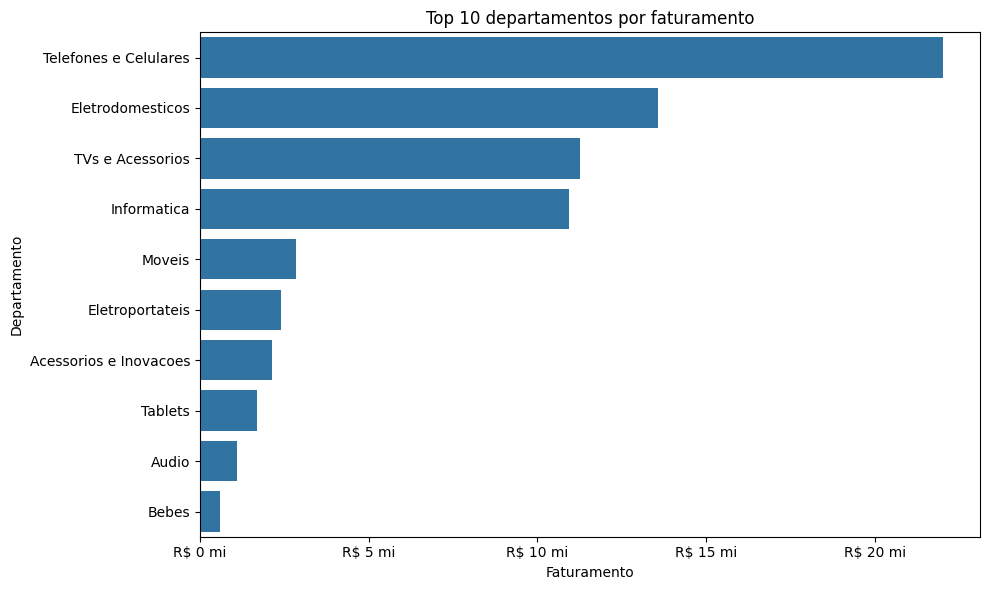

In [233]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_dep, x="Faturamento", y="Departamento")

ax = plt.gca()

ax.xaxis.set_major_formatter(
  FuncFormatter(
    lambda x, pos: f"R$ {x / 1_000_000:.0f} mi"
  )
)

plt.title("Top 10 departamentos por faturamento")
plt.xlabel("Faturamento")
plt.ylabel("Departamento")

plt.tight_layout()

plt.savefig("../images/top_departamentos_faturamento.png", dpi=300, bbox_inches="tight")

plt.show()

#### Principais resultados por departamento

A análise mostra uma forte concentração de faturamento em algumas categorias.

O departamento de **Telefones e Celulares** lidera o faturamento, representando **30,36%** da receita total.

Na sequência aparecem:

- **Eletrodomésticos:** 18,70%;
- **TVs e Acessórios:** 15,52%;
- **Informática:** 15,07%.

Somados, esses quatro departamentos representam aproximadamente **80% do faturamento total**, indicando uma concentração significativa da receita em produtos ligados principalmente a eletrônicos e tecnologia.

Esse resultado sugere que alterações de demanda, estoque ou preços nessas categorias podem exercer forte impacto sobre o desempenho geral da operação.


### 7.2 Participação dos departamentos no faturamento

Além do valor absoluto de faturamento, será calculada a participação percentual de cada departamento no total da receita.


In [234]:
part_dep = (fat_dep / fat_dep.sum() * 100).round(2)

part_dep.head(10)

Nome_Departamento
Telefones e Celulares     30.36
Eletrodomesticos          18.70
TVs e Acessorios          15.52
Informatica               15.07
Moveis                     3.93
Eletroportateis            3.31
Acessorios e Inovacoes     2.95
Tablets                    2.35
Audio                      1.53
Bebes                      0.84
Name: Preço_com_frete, dtype: float64

### 7.3 Desempenho por canal de venda

A análise por canal busca identificar quais meios de venda concentram maior faturamento e volume de registros comerciais.


#### 7.3.1 Validação das categorias de canal

Durante a análise dos canais de venda, foram identificadas categorias potencialmente equivalentes, como `Aplicativo` e `APP`.

Antes de interpretar o desempenho por canal, os valores serão revisados e padronizados para evitar que uma mesma categoria seja contabilizada separadamente devido a diferenças de nomenclatura.


In [235]:
vendas_clientes["idcanalvenda"].value_counts(dropna=False)

idcanalvenda
Mobile        27941
Internet      27734
Aplicativo    24008
APP             100
Name: count, dtype: int64

In [236]:
vendas_clientes["idcanalvenda"].unique()

array(['Mobile', 'APP', 'Internet', 'Aplicativo'], dtype=object)

In [237]:
vendas_clientes["idcanalvenda"] = vendas_clientes["idcanalvenda"].replace(
    {"APP": "Aplicativo"}
)

In [238]:
canal_analysis = (
    vendas_clientes.groupby("idcanalvenda")
    .agg(
        Faturamento=("Preço_com_frete", "sum"),
        Vendas=("idcompra", "size"),
        Clientes=("cliente_Log", "nunique"),
    )
    .sort_values("Faturamento", ascending=False)
)

In [239]:
canal_analysis_display = canal_analysis.reset_index().copy()

canal_analysis_display["Faturamento"] = canal_analysis_display["Faturamento"].map(
    lambda x: f"R$ {x:,.2f}"
)

canal_analysis_display

,idcanalvenda,Faturamento,Vendas,Clientes
0,Internet,"R$ 27,150,113.83",27734,13762
1,Mobile,"R$ 23,021,477.56",27941,13934
2,Aplicativo,"R$ 22,346,339.76",24108,13017


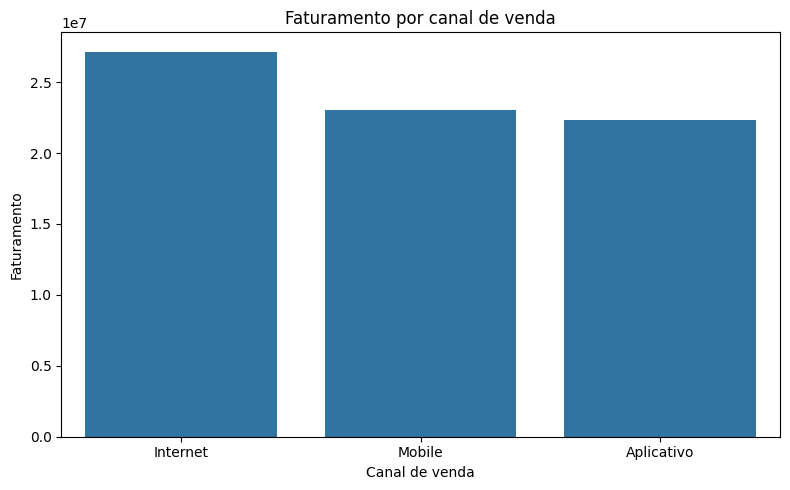

In [240]:
canal_plot = canal_analysis.reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(data=canal_plot, x="idcanalvenda", y="Faturamento")

plt.title("Faturamento por canal de venda")
plt.xlabel("Canal de venda")
plt.ylabel("Faturamento")

plt.tight_layout()
plt.show()

### 7.4 Desempenho geográfico

A análise por estado permite identificar as regiões com maior participação nas vendas e no faturamento da empresa.


In [241]:
estado_analysis = (
    vendas_clientes.groupby("estado")
    .agg(
        Faturamento=("Preço_com_frete", "sum"),
        Vendas=("idcompra", "size"),
        Clientes=("cliente_Log", "nunique"),
    )
    .sort_values("Faturamento", ascending=False)
)

In [242]:
estado_analysis_display = estado_analysis.head(10).reset_index().copy()

estado_analysis_display["Faturamento"] = estado_analysis_display["Faturamento"].map(
    lambda x: f"R$ {x:,.2f}"
)

estado_analysis_display

,estado,Faturamento,Vendas,Clientes
0,SP,"R$ 26,948,388.07",29839,14286
1,RJ,"R$ 16,033,258.46",17564,10992
2,MG,"R$ 10,243,956.25",11085,8147
3,RS,"R$ 3,777,341.98",4153,3663
4,PR,"R$ 2,452,249.06",2786,2590
5,BA,"R$ 1,935,435.65",2043,1923
6,SC,"R$ 1,786,121.34",1946,1850
7,DF,"R$ 1,742,567.49",1912,1812
8,PE,"R$ 1,529,346.52",1636,1549
9,GO,"R$ 1,422,048.30",1611,1539


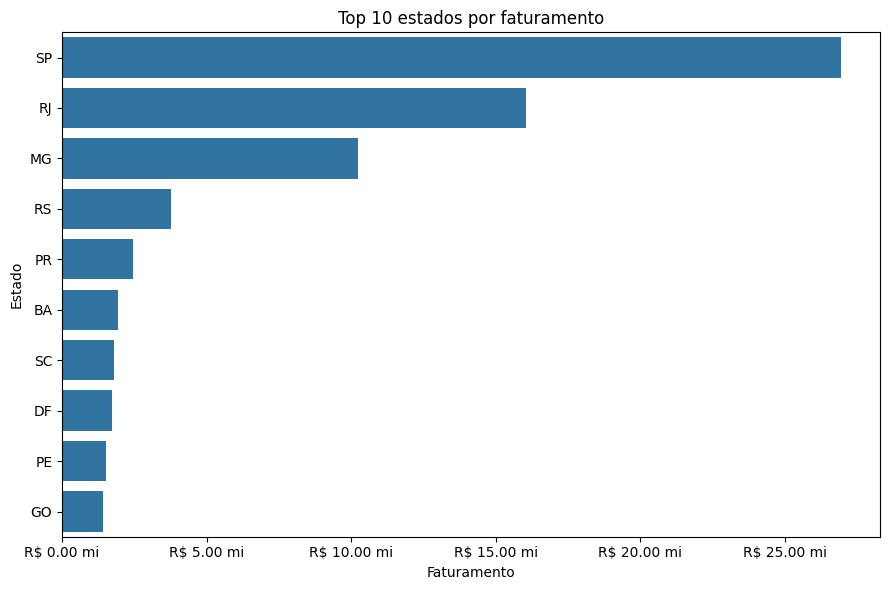

In [243]:
top_estados = estado_analysis.head(10).reset_index()

plt.figure(figsize=(9, 6))

sns.barplot(data=top_estados, x="Faturamento", y="estado")

ax = plt.gca()

ax.xaxis.set_major_formatter(
  FuncFormatter(
    lambda x, pos: f"R$ {x / 1_000_000:.2f} mi"
  )
)

plt.title("Top 10 estados por faturamento")
plt.xlabel("Faturamento")
plt.ylabel("Estado")

plt.tight_layout()

plt.savefig("../images/top_estados_faturamento.png", dpi=300, bbox_inches="tight")

plt.show()

### Principais resultados geográficos

O estado de **São Paulo** apresenta o maior faturamento da operação, com aproximadamente **R$ 26,95 milhões**, além do maior número de pedidos e clientes.

Na sequência aparecem:

- **Rio de Janeiro:** aproximadamente R$ 16,03 milhões;
- **Minas Gerais:** aproximadamente R$ 10,24 milhões;
- **Rio Grande do Sul:** aproximadamente R$ 3,78 milhões.

Os resultados mostram uma concentração relevante da operação na região Sudeste, especialmente nos estados de São Paulo, Rio de Janeiro e Minas Gerais.

Essa concentração pode ser relevante para decisões relacionadas a estoque, logística, campanhas regionais e expansão comercial.


## 8. Análise temporal das vendas

A análise temporal permite compreender como o desempenho comercial evolui ao longo do período disponível na base.

Nesta etapa serão avaliados:

- faturamento ao longo do tempo;
- quantidade de vendas;
- valor médio por venda;
- identificação de possíveis picos ou quedas no desempenho comercial.

A análise será realizada utilizando a coluna `Data` da base tratada de vendas.

In [244]:
print("Data mínima:", vendas_clientes["Data"].min())
print("Data Máxima:", vendas_clientes["Data"].max())
print("Tipo da coluna:", vendas_clientes["Data"].dtypes)

Data mínima: 2023-01-02 00:00:00
Data Máxima: 2023-04-30 00:00:00
Tipo da coluna: datetime64[ns]


### 8.1 Preparação das variáveis temporais

Para facilitar a análise da evolução das vendas, serão criadas variáveis auxiliares de ano, mês e período mensal a partir da data da compra.


In [245]:
vendas_clientes["Ano"] = vendas_clientes["Data"].dt.year
vendas_clientes["Mês"] = vendas_clientes["Data"].dt.month
vendas_clientes["Ano_Mês"] = vendas_clientes["Data"].dt.to_period("M")

In [246]:
vendas_clientes[["Data", "Ano", "Mês", "Ano_Mês"]].head()

,Data,Ano,Mês,Ano_Mês
0,2023-03-17,2023,3,2023-03
1,2023-03-06,2023,3,2023-03
2,2023-01-13,2023,1,2023-01
3,2023-03-31,2023,3,2023-03
4,2023-03-19,2023,3,2023-03


### 8.2 Evolução mensal do faturamento

O faturamento será agregado por mês para identificar períodos de maior e menor desempenho comercial.


In [247]:
fat_mensal = vendas_clientes.groupby("Ano_Mês")["Preço_com_frete"].sum().reset_index()

In [248]:
fat_mensal_display = fat_mensal.copy()

fat_mensal_display["Preço_com_frete"] = fat_mensal_display["Preço_com_frete"].map(
    lambda x: f"R$ {x:,.2f}"
)

fat_mensal_display

,Ano_Mês,Preço_com_frete
0,2023-01,"R$ 18,066,875.82"
1,2023-02,"R$ 16,982,676.99"
2,2023-03,"R$ 19,056,577.04"
3,2023-04,"R$ 18,411,801.30"


### 8.3 Visualização da evolução do faturamento

O gráfico abaixo apresenta a evolução do faturamento mensal ao longo do período analisado.


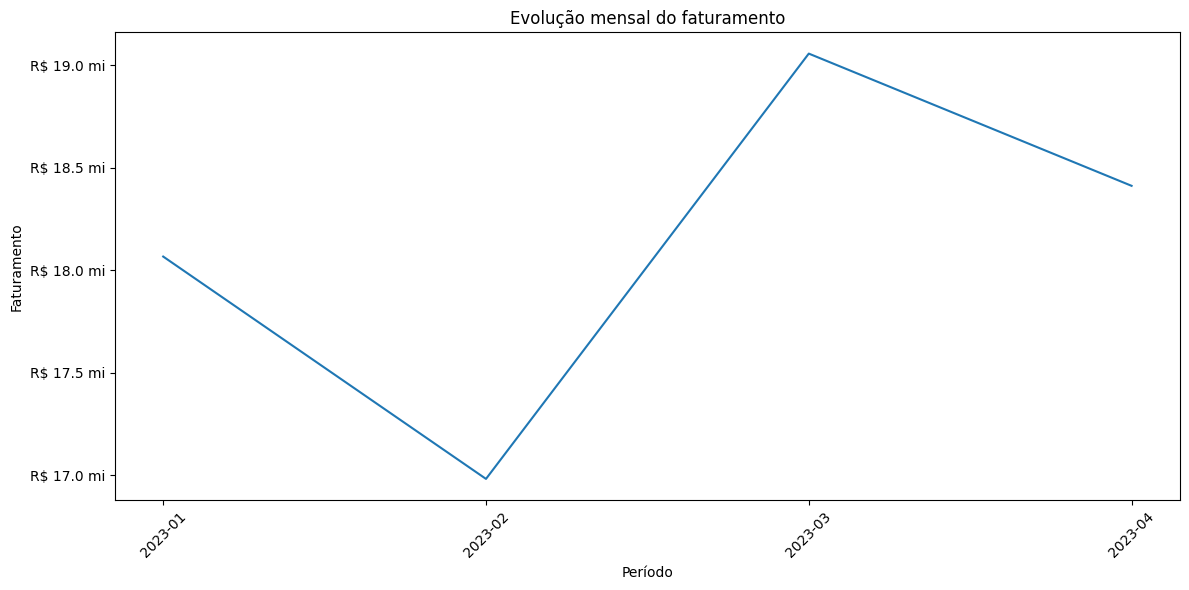

In [249]:
fat_mensal_plot = fat_mensal.copy()

fat_mensal_plot["Ano_Mês"] = fat_mensal_plot["Ano_Mês"].astype(str)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=fat_mensal_plot, x="Ano_Mês", y="Preço_com_frete", markers=0)

plt.title("Evolução mensal do faturamento")
plt.xlabel("Período")
plt.ylabel("Faturamento")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x / 1_000_000:.1f} mi"))

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/evolucao_fat_mensal.png", dpi=300, bbox_inches="tight")

plt.show()

### 8.4 Evolução da quantidade de vendas

Além do faturamento, será analisada a quantidade de vendas realizadas em cada período.

Essa comparação permite verificar se alterações na receita estão relacionadas ao volume de pedidos ou ao valor médio das compras.


In [250]:
vendas_mensais = (
    vendas_clientes.groupby("Ano_Mês").size().reset_index(name="Quant_Vendas")
)

vendas_mensais

,Ano_Mês,Quant_Vendas
0,2023-01,19875
1,2023-02,18921
2,2023-03,20867
3,2023-04,20120


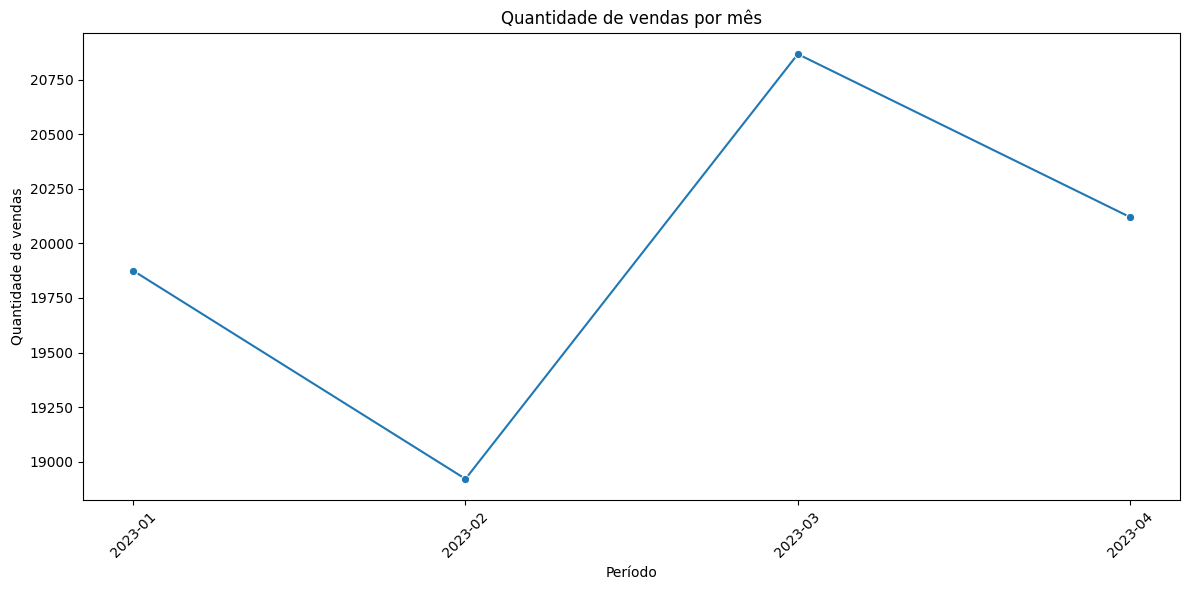

In [251]:
vendas_mensais_plot = vendas_mensais.copy()

vendas_mensais_plot["Ano_Mês"] = vendas_mensais_plot["Ano_Mês"].astype(str)

plt.figure(figsize=(12, 6))

sns.lineplot(data=vendas_mensais_plot, x="Ano_Mês", y="Quant_Vendas", marker="o")

plt.title("Quantidade de vendas por mês")
plt.xlabel("Período")
plt.ylabel("Quantidade de vendas")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/vendas_mensais.png", dpi=300, bbox_inches="tight")

plt.show()

### 8.5 Evolução do valor médio por venda

O valor médio mensal será calculado para avaliar se as variações de faturamento estão relacionadas apenas ao volume de transações ou também a mudanças no valor médio das compras realizadas.


In [252]:
valor_medio_mensal = (
    vendas_clientes.groupby("Ano_Mês")["Preço_com_frete"]
    .mean()
    .reset_index(name="Valor_Medio_Venda")
)

valor_medio_mensal_display = valor_medio_mensal.copy()

valor_medio_mensal_display["Valor_Medio_Venda"] = valor_medio_mensal_display[
    "Valor_Medio_Venda"
].map(lambda x: f"R$ {x:,.2f}")

valor_medio_mensal_display

,Ano_Mês,Valor_Medio_Venda
0,2023-01,R$ 909.03
1,2023-02,R$ 897.56
2,2023-03,R$ 913.24
3,2023-04,R$ 915.10


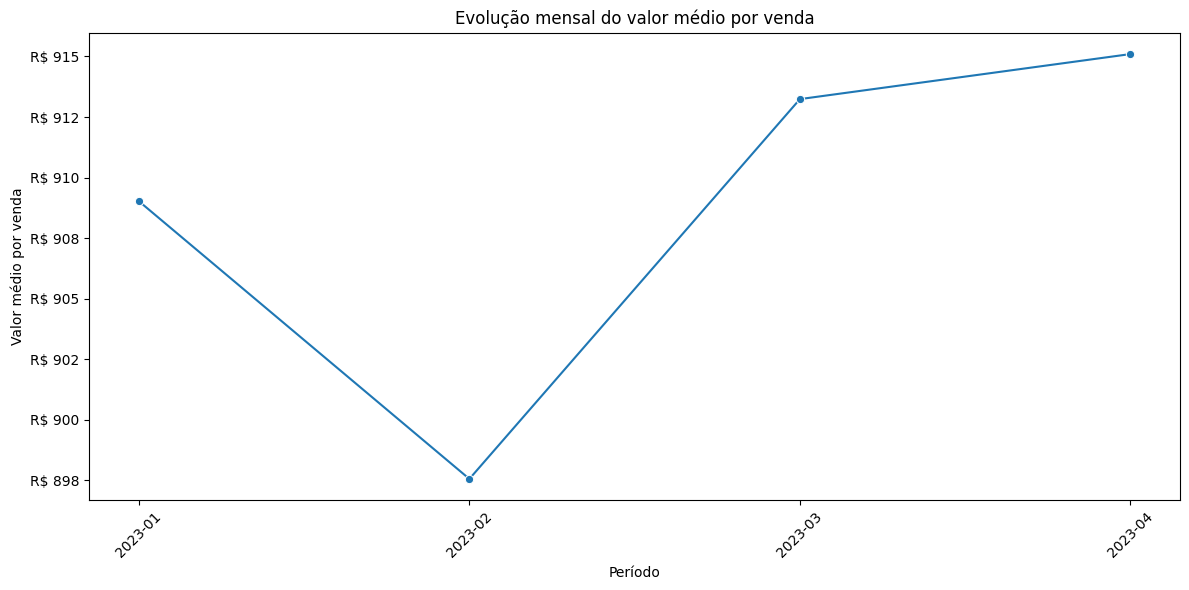

In [253]:
valor_medio_mensal_plot = valor_medio_mensal.copy()

valor_medio_mensal_plot["Ano_Mês"] = valor_medio_mensal_plot["Ano_Mês"].astype(str)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=valor_medio_mensal_plot, x="Ano_Mês", y="Valor_Medio_Venda", marker="o"
)

plt.title("Evolução mensal do valor médio por venda")
plt.xlabel("Período")
plt.ylabel("Valor médio por venda")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x:,.0f}"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 8.6 Principais resultados da análise temporal

A análise temporal mostrou variações relevantes no desempenho comercial ao longo dos quatro meses disponíveis na base.

#### Faturamento

O faturamento apresentou queda entre janeiro e fevereiro, seguida de uma recuperação significativa em março, que registrou o maior faturamento do período analisado.

Em abril houve uma redução em relação a março, porém o faturamento permaneceu acima dos níveis observados nos dois primeiros meses.

#### Quantidade de vendas

O volume de vendas apresentou comportamento semelhante ao faturamento:

- redução entre janeiro e fevereiro;
- forte crescimento em março;
- redução moderada em abril.

Março apresentou a maior quantidade de pedidos do período, indicando que o crescimento do faturamento nesse mês foi acompanhado por um aumento relevante no volume de compras.

#### Valor médio por venda

O valor médio por venda também caiu em fevereiro, porém apresentou crescimento nos meses seguintes.

Março combinou um volume elevado de vendas com um valor médio por venda superior ao observado em janeiro e fevereiro, contribuindo para o maior faturamento do período.

Em abril, apesar da redução na quantidade de pedidos em relação a março, o valor médio por venda continuou crescendo e atingiu seu maior nível no período analisado.

#### Síntese

Os resultados indicam que as variações de faturamento não estão relacionadas apenas ao número de pedidos.

Enquanto março se destacou pela combinação de **alto volume de vendas e aumento do valor médio por venda**, abril apresentou menor volume, porém maior valor médio por compra.

Essa análise mostra a importância de acompanhar conjuntamente faturamento, volume de vendas e valor médio por venda para compreender as mudanças no desempenho comercial.


## 9. Análise do perfil dos clientes

Nesta etapa, serão analisadas características do perfil dos clientes, com foco em idade, renda e comportamento de compra.

O objetivo é compreender melhor quem são os clientes da operação e identificar possíveis padrões de consumo entre diferentes perfis.


### 9.1 Estatísticas gerais do perfil dos clientes

Inicialmente serão analisadas as distribuições de idade e renda dos clientes consolidados.

Como a base original continha múltiplos registros para alguns clientes, esta análise utiliza a versão tratada `clientes_clean`, em que cada `cliente_Log` aparece apenas uma vez.


In [254]:
perfil_clientes = clientes_clean[["idade", "renda"]].describe().round(2)

In [255]:
perfil_clientes_display = perfil_clientes.copy()

perfil_clientes_display["renda"] = perfil_clientes_display["renda"].map(
    lambda x: f"R$ {x:,.2f}"
)

perfil_clientes_display

,idade,renda
count,17074.00,"R$ 17,074.00"
mean,53.38,"R$ 8,238.74"
std,18.62,"R$ 3,493.53"
min,18.00,"R$ 1,500.00"
25%,39.00,"R$ 5,491.00"
50%,53.00,"R$ 8,237.75"
75%,68.00,"R$ 11,009.75"
max,89.00,"R$ 14,999.00"


### 9.2 Distribuição de idade

A distribuição de idade permite identificar a faixa etária predominante entre os clientes e verificar a presença de valores extremos.


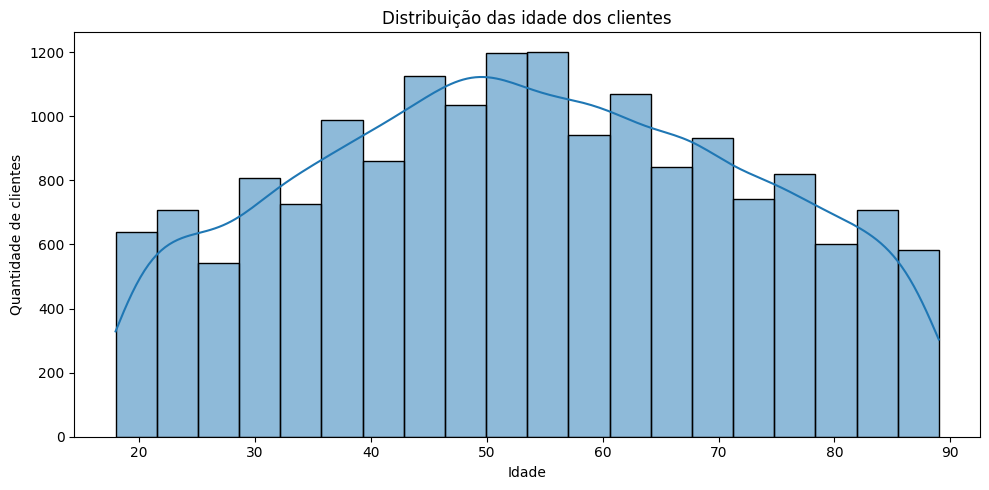

In [256]:
plt.figure(figsize=(10, 5))

sns.histplot(data=clientes_clean, x="idade", bins=20, kde=True)

plt.title("Distribuição das idade dos clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade de clientes")

plt.tight_layout()
plt.show()

### 9.3 Distribuição de renda

A análise de renda permite compreender o perfil econômico dos clientes e avaliar a dispersão dos valores observados na base.


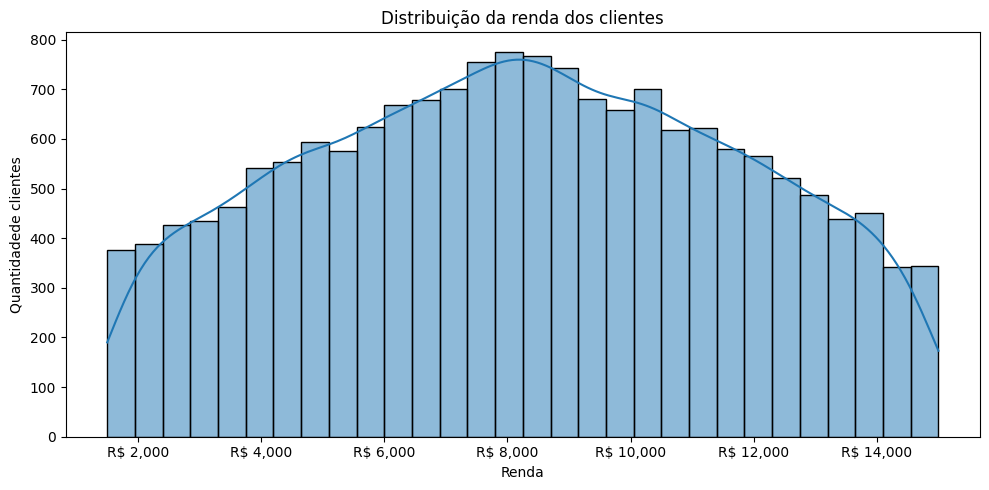

In [257]:
plt.figure(figsize=(10, 5))

sns.histplot(data=clientes_clean, x="renda", bins=30, kde=True)

plt.title("Distribuição da renda dos clientes")
plt.xlabel("Renda")
plt.ylabel("Quantidadede clientes")

ax = plt.gca()

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x:,.0f}"))

plt.tight_layout()
plt.show()

### 9.4 Perfil dos clientes compradores

Nem todos os clientes cadastrados necessariamente possuem compras válidas no período analisado.

Por isso, será analisado separadamente o perfil dos clientes que efetivamente possuem transações válidas na base tratada.


In [258]:
clientes_compras = vendas_clientes[["cliente_Log", "idade", "renda"]].drop_duplicates(
    subset="cliente_Log"
)

clientes_compras.shape

(17074, 3)

In [259]:
perfil_compradores = clientes_compras[["idade", "renda"]].describe().round(2)

In [260]:
perfil_compradores_display = perfil_compradores.copy()

perfil_compradores_display["renda"] = perfil_compradores_display["renda"].map(
    lambda x: f"R$ {x:,.2f}"
)

perfil_compradores_display

,idade,renda
count,17074.00,"R$ 17,074.00"
mean,53.38,"R$ 8,238.74"
std,18.62,"R$ 3,493.53"
min,18.00,"R$ 1,500.00"
25%,39.00,"R$ 5,491.00"
50%,53.00,"R$ 8,237.75"
75%,68.00,"R$ 11,009.75"
max,89.00,"R$ 14,999.00"


### 9.5 Comportamento de compra por cliente

Para compreender melhor o comportamento dos clientes, será criada uma visão consolidada com indicadores individuais de compra.

Para cada cliente serão calculados:

- faturamento total gerado;
- quantidade de vendas;
- valor médio por venda;
- idade;
- renda.

Essa visão permitirá investigar se características como idade e renda apresentam relação com o comportamento de consumo.


In [261]:
comp_clientes = vendas_clientes.groupby("cliente_Log", as_index=False).agg(
    idade=("idade", "first"),
    renda=("renda", "first"),
    Faturamento_Total=("Preço_com_frete", "sum"),
    quant_vendas=("idcompra", "size"),
    Valor_Medio_Venda=("Preço_com_frete", "mean"),
)

comp_clientes_display = comp_clientes.head(10).copy()

col_monetarias = ["renda", "Faturamento_Total", "Valor_Medio_Venda"]

for coluna in col_monetarias:
    comp_clientes_display[coluna] = comp_clientes_display[coluna].map(
        lambda x: f"R$ {x:,.2f}"
    )

comp_clientes_display

,cliente_Log,idade,renda,Faturamento_Total,quant_vendas,Valor_Medio_Venda
0,1,33.5,"R$ 9,294.00","R$ 7,409.55",6,"R$ 1,234.93"
1,3,52.5,"R$ 9,645.50","R$ 4,862.87",6,R$ 810.48
2,5,30.0,"R$ 6,518.00","R$ 10,995.10",10,"R$ 1,099.51"
3,7,78.0,"R$ 4,540.00","R$ 2,926.97",3,R$ 975.66
4,8,56.0,"R$ 12,616.00","R$ 6,366.97",6,"R$ 1,061.16"
5,9,80.0,"R$ 5,141.00","R$ 3,877.68",3,"R$ 1,292.56"
6,11,32.0,"R$ 12,330.00","R$ 4,300.80",3,"R$ 1,433.60"
7,14,19.0,"R$ 3,903.00","R$ 1,271.04",3,R$ 423.68
8,16,46.5,"R$ 3,580.00","R$ 5,619.28",6,R$ 936.55
9,18,77.0,"R$ 14,611.00","R$ 2,382.32",3,R$ 794.11


### 9.6 Distribuição do faturamento por cliente

A distribuição do faturamento acumulado por cliente permite avaliar se a receita está concentrada em uma pequena parcela da base ou distribuída de forma mais homogênea entre os consumidores.


In [262]:
comp_clientes["Faturamento_Total"].describe().round(2)

fat_cliente_stats = (
    comp_clientes["Faturamento_Total"].describe().to_frame(name="Faturamento_Total")
)

fat_cliente_stats_display = fat_cliente_stats.copy()

fat_cliente_stats_display["Faturamento_Total"] = fat_cliente_stats_display[
    "Faturamento_Total"
].map(lambda x: f"R$ {x:,.2f}")

fat_cliente_stats_display.loc["count", "Faturamento_Total"] = (
    f"{int(fat_cliente_stats.loc['count', 'Faturamento_Total']):,}"
)

fat_cliente_stats_display

,Faturamento_Total
count,"17,074"
mean,"R$ 4,247.27"
std,"R$ 3,198.73"
min,R$ 96.16
25%,"R$ 1,903.60"
50%,"R$ 3,500.71"
75%,"R$ 5,679.69"
max,"R$ 32,879.51"


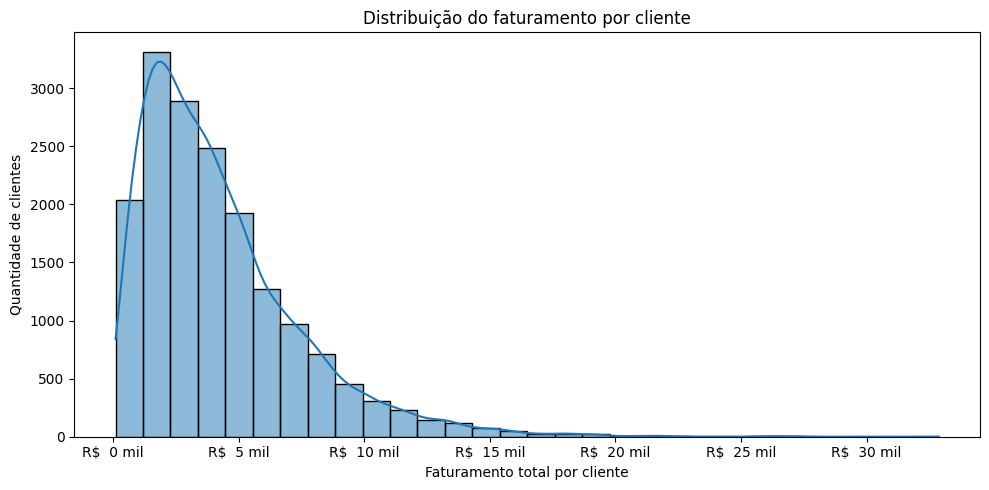

In [263]:
plt.figure(figsize=(10, 5))

ax = sns.histplot(data=comp_clientes, x="Faturamento_Total", bins=30, kde=True)

plt.title("Distribuição do faturamento por cliente")
plt.xlabel("Faturamento total por cliente")
plt.ylabel("Quantidade de clientes")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x / 1_000: .0f} mil"))

plt.tight_layout()
plt.show()

### 9.7 Relação entre renda e faturamento

Será analisada a relação entre a renda dos clientes e o faturamento acumulado gerado por cada consumidor.

O objetivo é verificar se clientes de maior renda tendem a apresentar maior volume financeiro de compras.


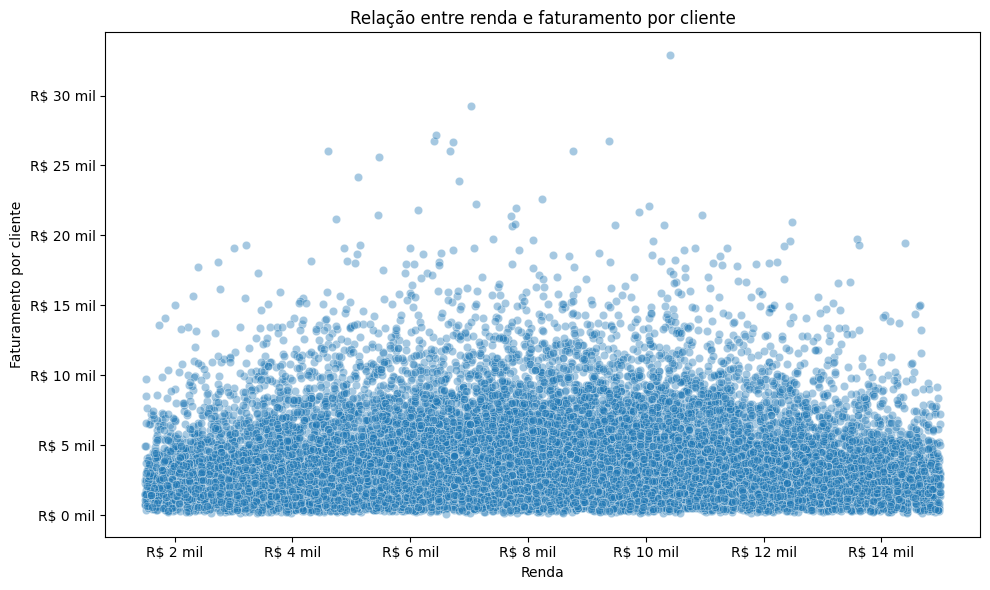

In [264]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=comp_clientes, x="renda", y="Faturamento_Total", alpha=0.4)

plt.title("Relação entre renda e faturamento por cliente")
plt.xlabel("Renda")
plt.ylabel("Faturamento por cliente")

ax = plt.gca()

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x / 1_000:.0f} mil"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x / 1_000:.0f} mil"))

plt.tight_layout()
plt.show()

In [265]:
corr_renda_fat = comp_clientes[["renda", "Faturamento_Total"]].corr().iloc[0, 1]

print(f"Correlação entre renda e faturamento: " f"{corr_renda_fat:.3f}")

Correlação entre renda e faturamento: 0.003


### 9.8 Relação entre idade e faturamento

Também será investigada a relação entre a idade dos clientes e o faturamento acumulado.

Essa análise permite avaliar se determinadas faixas etárias apresentam comportamento de consumo financeiro mais elevado.


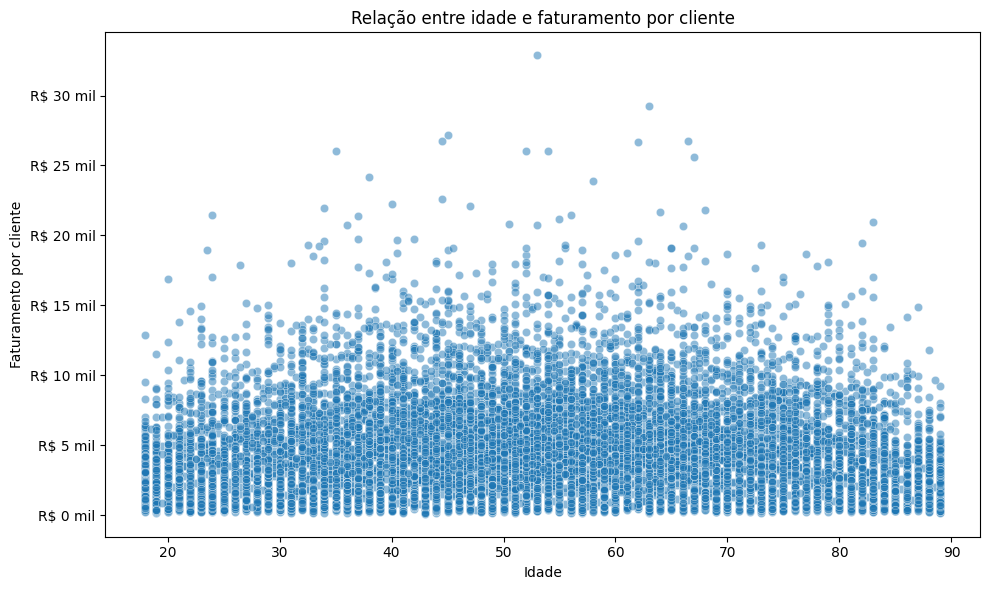

In [266]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=comp_clientes, x="idade", y="Faturamento_Total", alpha=0.5)

plt.title("Relação entre idade e faturamento por cliente")
plt.xlabel("Idade")
plt.ylabel("Faturamento por cliente")

ax = plt.gca()

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"R$ {x / 1_000:.0f} mil"))

plt.tight_layout()
plt.show()

In [267]:
corr_idade_fat = comp_clientes[["idade", "Faturamento_Total"]].corr().iloc[0, 1]

print(f"Correlação entre idade e faturamento; " f"{corr_idade_fat:.3f}")

Correlação entre idade e faturamento; -0.002


### 9.9 Principais resultados do perfil e comportamento dos clientes

A análise consolidada por cliente mostrou diferenças relevantes no volume financeiro gerado pelos consumidores.

O faturamento médio por cliente foi de aproximadamente **R$ 4.247,27**, enquanto a mediana foi de **R$ 3.500,71**.

Os quartis indicam que:

- 25% dos clientes geraram até aproximadamente **R$ 1.903,60** em faturamento;
- 50% geraram até aproximadamente **R$ 3.500,71**;
- 75% geraram até aproximadamente **R$ 5.679,69**;
- o maior faturamento individual observado foi de aproximadamente **R$ 32.879,51**.

Essa diferença entre média, mediana e valor máximo indica a presença de clientes com níveis de consumo significativamente superiores aos demais.

#### Relação entre renda e faturamento

A correlação entre renda e faturamento foi de aproximadamente **0,003**.

Esse valor é muito próximo de zero, indicando que não foi observada relação linear relevante entre a renda cadastrada do cliente e o faturamento acumulado no período analisado.

Portanto, clientes com maior renda não necessariamente geraram maior faturamento.

#### Relação entre idade e faturamento

A correlação entre idade e faturamento foi de aproximadamente **-0,002**.

Assim como na análise de renda, o valor está extremamente próximo de zero, indicando ausência de relação linear relevante entre idade e faturamento.

Esses resultados sugerem que idade e renda, analisadas isoladamente, não são suficientes para explicar diferenças no comportamento de compra dos clientes.

Características relacionadas ao histórico de consumo, frequência de compras e valor gasto podem ser mais úteis para a segmentação comercial.


## 10. Segmentação de clientes

Após analisar o perfil e o comportamento de compra, será realizada uma segmentação analítica dos clientes com base em indicadores comerciais.

A segmentação utilizará principalmente:

- frequência de compras;
- faturamento total;
- valor médio por venda.

O objetivo é identificar grupos de clientes com comportamentos distintos e gerar informações úteis para estratégias de relacionamento, retenção e priorização comercial.


In [268]:
metricas_segmen = (
    comp_clientes[["quant_vendas", "Faturamento_Total", "Valor_Medio_Venda"]]
    .describe()
    .round(2)
)

metricas_segmen_display = metricas_segmen.copy()

metricas_segmen_display["Faturamento_Total"] = metricas_segmen_display[
    "Faturamento_Total"
].map(lambda x: f"R$ {x:,.2f}")

metricas_segmen_display["Valor_Medio_Venda"] = metricas_segmen_display[
    "Valor_Medio_Venda"
].map(lambda x: f"R$ {x:,.2f}")

metricas_segmen_display.loc["count", "Faturamento_Total"] = (
    f"{int(metricas_segmen.loc['count', 'Faturamento_Total'])}"
)

metricas_segmen_display.loc["count", "Valor_Medio_Venda"] = (
    f"{int(metricas_segmen.loc['count', 'Valor_Medio_Venda']):,}"
)

metricas_segmen_display

,quant_vendas,Faturamento_Total,Valor_Medio_Venda
count,17074.00,17074,"17,074"
mean,4.67,"R$ 4,247.27",R$ 906.20
std,2.40,"R$ 3,198.73",R$ 533.27
min,2.00,R$ 96.16,R$ 32.05
25%,3.00,"R$ 1,903.60",R$ 527.68
50%,3.00,"R$ 3,500.71",R$ 818.26
75%,6.00,"R$ 5,679.69","R$ 1,179.24"
max,24.00,"R$ 32,879.51","R$ 5,685.39"


### 10.1 Segmentação por valor gerado

Os clientes serão divididos em grupos com base no faturamento total acumulado.

Para evitar cortes arbitrários, serão utilizados quartis da própria distribuição dos dados.

Essa abordagem permite classificar os clientes relativamente ao comportamento observado na base.


In [269]:
comp_clientes["Segmento_Valor"] = pd.qcut(
    comp_clientes["Faturamento_Total"],
    q=4,
    labels=["Baixo valor", "Médio-baixo valor", "Médio-alto valor", "Alto valor"],
)

comp_clientes["Segmento_Valor"].value_counts()

Segmento_Valor
Baixo valor          4269
Alto valor           4269
Médio-baixo valor    4268
Médio-alto valor     4268
Name: count, dtype: int64

### 10.2 Perfil dos segmentos de clientes

Após a classificação dos clientes por valor gerado, serão comparados seus principais indicadores de comportamento de compra.


In [270]:
perfil_segmen = comp_clientes.groupby("Segmento_Valor", observed=True).agg(
    Clientes=("cliente_Log", "count"),
    Faturamento_Medio=("Faturamento_Total", "mean"),
    Vendas_Medias=("quant_vendas", "mean"),
    Valor_Medio_Venda=("Valor_Medio_Venda", "mean"),
)

perfil_segmen_display = perfil_segmen.copy()

perfil_segmen_display["Faturamento_Medio"] = perfil_segmen_display[
    "Faturamento_Medio"
].map(lambda x: f"R$ {x:,.2f}")

perfil_segmen_display["Valor_Medio_Venda"] = perfil_segmen_display[
    "Valor_Medio_Venda"
].map(lambda x: f"R$ {x:,.2f}")

perfil_segmen_display["Vendas_Medias"] = perfil_segmen_display["Vendas_Medias"].map(
    lambda x: f"{x:.2f}"
)

perfil_segmen_display

,Clientes,Faturamento_Medio,Vendas_Medias,Valor_Medio_Venda
Segmento_Valor,,,,
Baixo valor,4269,"R$ 1,164.14",3.14,R$ 377.25
Médio-baixo valor,4268,"R$ 2,669.97",3.75,R$ 779.20
Médio-alto valor,4268,"R$ 4,482.85",4.69,"R$ 1,099.14"
Alto valor,4269,"R$ 8,671.81",7.10,"R$ 1,369.24"


### 10.3 Principais resultados da segmentação por valor

A divisão por quartis gerou quatro segmentos com tamanhos semelhantes, permitindo comparar grupos de clientes em diferentes níveis de valor para o negócio.

Os resultados mostram uma evolução consistente entre os segmentos.

#### Baixo valor

Os clientes classificados como **Baixo valor** apresentam:

- faturamento médio de aproximadamente **R$ 1.164,14**;
- média de **3,14 vendas**;
- valor médio por venda de aproximadamente **R$ 377,25**.

#### Médio-baixo valor

O segmento **Médio-baixo valor** apresenta:

- faturamento médio de aproximadamente **R$ 2.669,97**;
- média de **3,75 vendas**;
- valor médio por venda de aproximadamente **R$ 779,20**.

#### Médio-alto valor

Os clientes de **Médio-alto valor** apresentam:

- faturamento médio de aproximadamente **R$ 4.482,85**;
- média de **4,69 vendas**;
- valor médio por venda de aproximadamente **R$ 1.099,14**.

#### Alto valor

O segmento de **Alto valor** se destaca significativamente dos demais, apresentando:

- faturamento médio de aproximadamente **R$ 8.671,81**;
- média de **7,10 vendas**;
- valor médio por venda de aproximadamente **R$ 1.369,24**.

Os resultados mostram que os clientes de maior valor não se diferenciam apenas pelo montante gasto em uma compra individual.

Eles também apresentam **maior frequência de compras**, indicando que o faturamento elevado é resultado da combinação entre recorrência e maior valor médio por venda.

Esse grupo pode representar uma parcela estratégica da base de clientes e merece atenção especial em ações de relacionamento, fidelização e retenção.


### 10.4 Identificação de clientes de alto valor e alta frequência

Além da segmentação por faturamento, será identificado um grupo estratégico composto por clientes que apresentam simultaneamente alto valor gerado e alta frequência de compras.

Para evitar limites arbitrários, serão utilizados os percentis de 75% das variáveis `Faturamento_Total` e `quant_vendas`.

Clientes acima de ambos os limites serão classificados como clientes estratégicos de alto valor e alta frequência.


In [271]:
limite_fat = comp_clientes["Faturamento_Total"].quantile(0.75)

limite_freque = comp_clientes["quant_vendas"].quantile(0.75)

print(f"Limite de faturamento: R$ {limite_fat:,.2f}")
print(f"Limite de frequência:{limite_freque:.0f} vendas")

Limite de faturamento: R$ 5,679.69
Limite de frequência:6 vendas


In [272]:
comp_clientes["Cliente_Estrategico"] = (
    comp_clientes["Faturamento_Total"] >= limite_fat
) & (comp_clientes["quant_vendas"] >= limite_freque)

clientes_estrategicos = comp_clientes[comp_clientes["Cliente_Estrategico"]].copy()

print("Clientes Estratégicos:", clientes_estrategicos.shape[0])
print(
    "Percentual da base:",
    f"{clientes_estrategicos.shape[0] / comp_clientes.shape[0] * 100:.2f}",
)

Clientes Estratégicos: 3577
Percentual da base: 20.95


In [273]:
fat_estrategicos = clientes_estrategicos["Faturamento_Total"].sum()

part_estrategicos = fat_estrategicos / comp_clientes["Faturamento_Total"].sum() * 100

print(f"Faturamento dos clientes estratégicos: " f"R$ {fat_estrategicos:,.2f}")

print(f"Participação no faturamento total: " f"{part_estrategicos:.2f}%")

Faturamento dos clientes estratégicos: R$ 31,984,058.75
Participação no faturamento total: 44.11%


### 10.5 Principais resultados dos clientes estratégicos

A análise identificou **3.577 clientes estratégicos**, definidos como consumidores que apresentam simultaneamente faturamento e frequência de compras iguais ou superiores ao terceiro quartil da distribuição.

Esses clientes representam aproximadamente **20,95% da base total**, porém são responsáveis por cerca de **44,11% do faturamento**, gerando aproximadamente **R$ 31,98 milhões** no período analisado.

Os limites utilizados para essa classificação foram:

- faturamento mínimo de aproximadamente **R$ 5.679,69**;
- frequência mínima de **6 vendas**.

Os resultados mostram uma concentração relevante de receita em uma parcela relativamente pequena da base de clientes.

Esse grupo possui importância estratégica para o negócio, pois combina maior recorrência de compras com maior geração de receita.

Ações específicas de relacionamento, fidelização e retenção podem ser especialmente relevantes para preservar e ampliar o valor gerado por esses consumidores.


## 11. Recorrência e concentração de valor

Nesta etapa será analisado como o faturamento está distribuído entre os clientes e qual é o nível de recorrência de compras da base.

O objetivo é compreender:

- quantos clientes realizaram compras recorrentes;
- qual parcela realizou poucas ou muitas compras;
- quanto do faturamento está concentrado nos clientes de maior valor;
- se existe dependência relevante de uma pequena parcela da base.


### 11.1 Distribuição da frequência de compras

A frequência de compras será analisada para identificar o nível de recorrência dos clientes ao longo do período disponível.


In [274]:
frequencia_clientes = comp_clientes["quant_vendas"].value_counts().sort_index()

frequencia_clientes

quant_vendas
2      118
3     9815
4      322
5      108
6     4469
7      281
8       44
9     1328
10     127
11      15
12     314
13      34
14       4
15      71
16       9
17       2
18       9
19       2
21       1
24       1
Name: count, dtype: int64

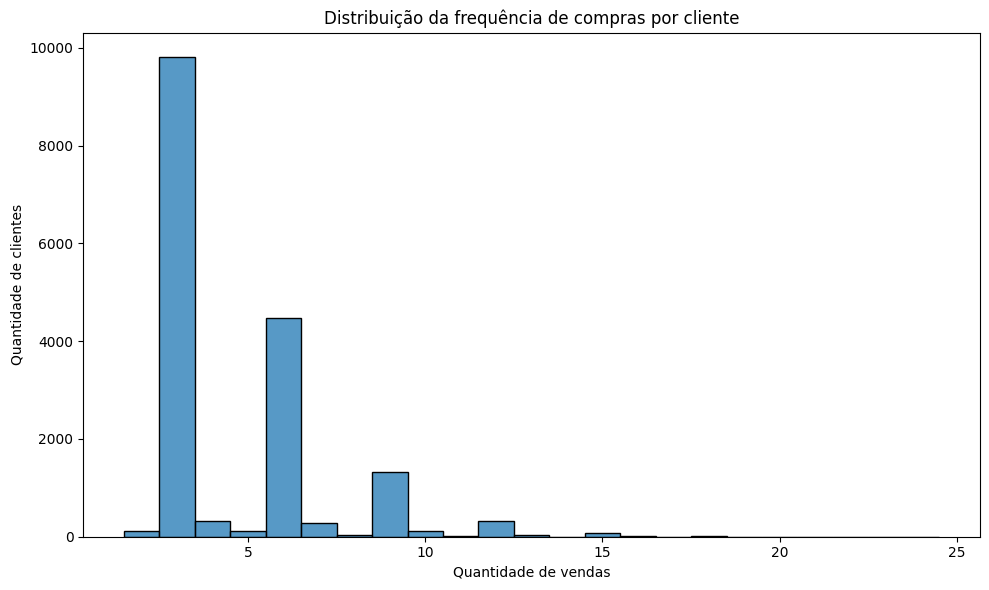

In [275]:
plt.figure(figsize=(10, 6))

sns.histplot(data=comp_clientes, x="quant_vendas", discrete=True)

plt.title("Distribuição da frequência de compras por cliente")
plt.xlabel("Quantidade de vendas")
plt.ylabel("Quantidade de clientes")

plt.tight_layout()

plt.savefig("../images/freq_compras_clientes.png", dpi=300, bbox_inches="tight")

plt.show()

### 11.2 Segmentação por frequência de compras

A definição tradicional de cliente recorrente como aquele que realizou mais de uma compra não é discriminativa nesta base, pois todos os clientes analisados possuem pelo menos duas vendas registradas.

Por esse motivo, será utilizada uma segmentação relativa de frequência baseada na própria distribuição dos dados.

Os clientes serão divididos em três grupos:

- **Baixa frequência:** quantidade de vendas menor ou igual à mediana;
- **Média frequência:** acima da mediana e abaixo do terceiro quartil;
- **Alta frequência:** quantidade de vendas igual ou superior ao terceiro quartil.

Essa abordagem permite comparar níveis diferentes de recorrência sem utilizar limites arbitrários.


In [276]:
mediana_freq = comp_clientes["quant_vendas"].median()

q75_freq = comp_clientes["quant_vendas"].quantile(0.75)

print(f"Mediana de frequência: {mediana_freq:.0f} vendas")

print(f"Terceiro quartil: {q75_freq:.0f} vendas")

Mediana de frequência: 3 vendas
Terceiro quartil: 6 vendas


### 11.3 Classificação dos clientes por frequência

Com base nos limites identificados na distribuição, cada cliente será classificado em um nível de frequência de compras.


In [277]:
def classificar_freq(vendas):
    if vendas <= mediana_freq:
        return "Baixa frequência"
    elif vendas < q75_freq:
        return "Média frequência"
    else:
        return "Alta frequência"


comp_clientes["Segmento_Frequencia"] = comp_clientes["quant_vendas"].apply(
    classificar_freq
)

comp_clientes["Segmento_Frequencia"].value_counts()

Segmento_Frequencia
Baixa frequência    9933
Alta frequência     6711
Média frequência     430
Name: count, dtype: int64

### 11.4 Perfil dos segmentos de frequência

Os grupos serão comparados em termos de quantidade de clientes, faturamento total, faturamento médio e valor médio por venda.

Essa comparação permite avaliar o impacto financeiro associado à recorrência de compras.


In [278]:
perfil_freq = (
    comp_clientes.groupby("Segmento_Frequencia")
    .agg(
        Clientes=("cliente_Log", "count"),
        Faturamento_Total=("Faturamento_Total", "sum"),
        Faturamento_Medio=("Faturamento_Total", "mean"),
        Vendas_Medias=("quant_vendas", "mean"),
        Valor_Medio_Venda=("Valor_Medio_Venda", "mean"),
    )
    .sort_values("Faturamento_Total", ascending=False)
)

perfil_freq_display = perfil_freq.copy()

for coluna in ["Faturamento_Total", "Faturamento_Medio", "Valor_Medio_Venda"]:
    perfil_freq_display[coluna] = perfil_freq_display[coluna].map(
        lambda x: f"R$ {x:,.2f}"
    )

perfil_freq_display["Vendas_Medias"] = perfil_freq_display["Vendas_Medias"].map(
    lambda x: f"{x:.2f}"
)

perfil_freq_display

,Clientes,Faturamento_Total,Faturamento_Medio,Vendas_Medias,Valor_Medio_Venda
Segmento_Frequencia,,,,,
Alta frequência,6711,"R$ 44,130,762.58","R$ 6,575.88",7.19,R$ 913.57
Baixa frequência,9933,"R$ 26,794,504.06","R$ 2,697.52",2.99,R$ 902.64
Média frequência,430,"R$ 1,592,664.52","R$ 3,703.87",4.25,R$ 873.62


In [279]:
part_freq = (
    perfil_freq["Faturamento_Total"] / perfil_freq["Faturamento_Total"].sum() * 100
).round(2)

part_freq

Segmento_Frequencia
Alta frequência     60.85
Baixa frequência    36.95
Média frequência     2.20
Name: Faturamento_Total, dtype: float64

### 11.5 Concentração de faturamento nos clientes de maior valor

Para avaliar o nível de concentração da receita, será calculada a participação no faturamento dos 10% de clientes com maior faturamento acumulado.

Essa análise permite avaliar quanto da receita está concentrada entre os consumidores de maior valor para o negócio.

In [280]:
comp_clientes_ordenado = comp_clientes.sort_values(
    "Faturamento_Total", ascending=False
).copy()

quant_top_10 = int(np.ceil(comp_clientes_ordenado.shape[0] * 0.10))

top_10_clientes = comp_clientes_ordenado.head(quant_top_10)

fat_top_10 = top_10_clientes["Faturamento_Total"].sum()

part_top_10 = fat_top_10 / comp_clientes_ordenado["Faturamento_Total"].sum() * 100

print(f"Quantidade de clientes no top 10%:" f"{quant_top_10:,}")

print(f"Faturamento do top 10%: " f"{fat_top_10:,.2f}")

print(f"Participação no faturamento total: " f"{part_top_10:.2f}%")

Quantidade de clientes no top 10%:1,708
Faturamento do top 10%: 19,359,221.32
Participação no faturamento total: 26.70%


### 11.6 Principais resultados da análise de frequência e concentração

A distribuição da frequência de compras mostrou diferenças relevantes entre os grupos de clientes.

A mediana da base é de **3 vendas**, enquanto o terceiro quartil corresponde a **6 vendas**. Esses valores foram utilizados como limites para a classificação dos níveis de frequência.

#### Alta frequência

O grupo de **Alta frequência** reúne **6.711 clientes** e apresenta:

- média de **7,19 vendas por cliente**;
- faturamento médio de aproximadamente **R$ 6.575,88**;
- valor médio por venda de aproximadamente **R$ 913,57**;
- participação de **60,85% no faturamento total**.

Esse resultado mostra que os clientes com maior frequência representam o grupo mais relevante financeiramente para a operação.

#### Baixa frequência

O grupo de **Baixa frequência** possui **9.933 clientes** e apresenta:

- média de **2,99 vendas por cliente**;
- faturamento médio de aproximadamente **R$ 2.697,52**;
- valor médio por venda de aproximadamente **R$ 902,64**;
- participação de **36,95% no faturamento total**.

Embora seja o maior grupo em quantidade de clientes, sua participação relativa no faturamento é significativamente inferior à observada entre clientes de alta frequência.

#### Média frequência

O grupo de **Média frequência** reúne **430 clientes**, com:

- média de **4,25 vendas por cliente**;
- faturamento médio de aproximadamente **R$ 3.703,87**;
- valor médio por venda de aproximadamente **R$ 873,62**;
- participação de **2,20% no faturamento total**.

A menor quantidade de clientes nesse segmento ocorre porque a frequência é uma variável discreta: com os limites definidos pela mediana e pelo terceiro quartil, esse grupo concentra essencialmente clientes com 4 ou 5 vendas.

#### Síntese

Os resultados indicam que a frequência de compra possui forte relevância comercial.

Clientes de alta frequência geram a maior parcela do faturamento e apresentam faturamento médio por cliente significativamente superior aos demais grupos.

Por outro lado, o valor médio por venda varia menos entre os segmentos do que o faturamento total, sugerindo que a principal diferença entre os grupos está relacionada à **recorrência de compras**, e não apenas ao valor de cada transação.

Esse resultado reforça a importância de estratégias voltadas para aumento de frequência, fidelização e retenção de clientes.


## 12. Principais insights de negócio

Após as análises de desempenho comercial, comportamento de clientes, segmentação e frequência de compras, os principais resultados serão consolidados em uma visão orientada ao negócio.

O objetivo desta etapa é transformar os resultados analíticos em informações claras e acionáveis para apoiar decisões comerciais.


### 12.1 Resumo executivo dos indicadores

Os principais indicadores do período analisado são apresentados a seguir.


In [281]:
resumo_kpis = pd.DataFrame(
    {
        "Indicador": [
            "Faturamento total",
            "Quantidade de vendas",
            "Valor médio por venda",
            "Clientes únicos",
            "Clientes estratégicos",
            "Participação dos clientes estratégicos",
            "Participação do Top 10% dos clientes",
        ],
        "Valor": [
            fat_total,
            quant_vendas,
            valor_medio_venda,
            clientes_unicos,
            clientes_estrategicos.shape[0],
            part_estrategicos,
            part_top_10,
        ],
    }
)

resumo_kpis_display = pd.DataFrame(
    {
        "Indicador": [
            "Faturamento total",
            "Quantidade de vendas",
            "Valor médio por venda",
            "Clientes únicos",
            "Clientes estratégicos",
            "Participação dos clientes estratégicos",
            "Participação do Top 10% dos clientes",
        ],
        "Valor": [
            f"R$ {fat_total:,.2f}",
            f"{quant_vendas:,}",
            f"R$ {valor_medio_venda:,.2f}",
            f"{clientes_unicos:,}",
            f"{clientes_estrategicos.shape[0]:,}",
            f"{part_estrategicos:.2f}%",
            f"{part_top_10:.2f}%",
        ],
    }
)

resumo_kpis_display

,Indicador,Valor
0,Faturamento total,"R$ 72,517,931.15"
1,Quantidade de vendas,"79,783"
2,Valor médio por venda,R$ 908.94
3,Clientes únicos,"17,074"
4,Clientes estratégicos,"3,577"
5,Participação dos clientes estratégicos,44.11%
6,Participação do Top 10% dos clientes,26.70%


### 12.2 Insights comerciais consolidados

A análise dos dados permite destacar alguns padrões relevantes para o negócio:

1. **Forte concentração em categorias de tecnologia**  
   Telefones e Celulares, Eletrodomésticos, TVs e Acessórios e Informática concentram aproximadamente 80% do faturamento, demonstrando elevada importância dessas categorias para o desempenho comercial.

2. **Concentração geográfica no Sudeste**  
   São Paulo, Rio de Janeiro e Minas Gerais aparecem entre os estados de maior faturamento, indicando forte participação da região Sudeste na operação.

3. **Março apresentou o melhor desempenho temporal**  
   O mês combinou maior volume de vendas com aumento do valor médio das transações, resultando no maior faturamento entre os períodos analisados.

4. **Idade e renda não explicam o faturamento individual**  
   As correlações observadas entre faturamento e idade ou renda ficaram próximas de zero, indicando baixa relação linear entre essas características demográficas e o valor gerado pelos clientes.

5. **Frequência é um fator relevante na geração de receita**  
   Clientes de alta frequência são responsáveis por 60,85% do faturamento, demonstrando que a recorrência possui papel importante no desempenho comercial.

6. **Clientes estratégicos possuem participação desproporcional na receita**  
   Aproximadamente 20,95% dos clientes classificados como estratégicos são responsáveis por 44,11% do faturamento total.

7. **Os 10% de clientes de maior valor possuem participação relevante**  
   Os clientes com maior faturamento acumulado respondem por aproximadamente 26,70% da receita total, evidenciando concentração moderada do faturamento em consumidores de maior valor.

## 13. Recomendações de negócio

Com base nos resultados obtidos ao longo da análise, algumas ações podem ser consideradas para melhorar o desempenho comercial, aumentar a recorrência de compras e fortalecer o relacionamento com clientes de maior valor.

### 13.1 Priorizar clientes estratégicos

Os clientes classificados como estratégicos representam aproximadamente **20,95% da base**, mas são responsáveis por cerca de **44,11% do faturamento total**.

Esse grupo combina maior frequência de compras com maior geração de receita.

Recomenda-se:

- desenvolver campanhas de fidelização específicas;
- criar benefícios progressivos por recorrência;
- oferecer atendimento prioritário;
- utilizar ações de retenção para reduzir a perda de clientes de alto valor;
- acompanhar individualmente mudanças relevantes no comportamento de compra desse segmento.

### 13.2 Estimular o aumento da frequência de compras

Clientes de alta frequência representam **60,85% do faturamento total**, demonstrando forte relação entre recorrência e geração de receita.

Por outro lado, o valor médio por venda varia menos entre os segmentos do que a frequência de compras.

Isso indica que aumentar a recorrência pode ser uma estratégia mais relevante do que buscar apenas elevar o valor de uma única transação.

Recomenda-se:

- criar campanhas de recompra;
- desenvolver programas de fidelidade;
- oferecer benefícios após determinado número de compras;
- utilizar comunicação personalizada com clientes de baixa e média frequência;
- identificar oportunidades de cross-sell entre departamentos relacionados.

### 13.3 Proteger as categorias de maior faturamento

Os departamentos de **Telefones e Celulares**, **Eletrodomésticos**, **TVs e Acessórios** e **Informática** concentram aproximadamente **80% do faturamento total**.

Essa concentração torna essas categorias especialmente relevantes para o desempenho da empresa.

Recomenda-se:

- priorizar disponibilidade de estoque nessas categorias;
- acompanhar rupturas e níveis de estoque com maior frequência;
- avaliar margem de contribuição por departamento;
- monitorar alterações de demanda;
- utilizar produtos complementares para estratégias de cross-sell.

### 13.4 Desenvolver estratégias regionais

São Paulo, Rio de Janeiro e Minas Gerais concentram parcela relevante do faturamento, indicando forte presença comercial na região Sudeste.

Recomenda-se:

- direcionar campanhas regionais de acordo com o desempenho de cada estado;
- avaliar diferenças de comportamento entre regiões;
- priorizar logística e disponibilidade de produtos em mercados de maior demanda;
- identificar oportunidades de expansão em estados com menor participação.

### 13.5 Investigar os fatores associados ao desempenho de março

Março apresentou o maior faturamento do período analisado, combinando crescimento no volume de vendas com aumento do valor médio por transação.

Recomenda-se investigar fatores que possam ter contribuído para esse resultado, como:

- campanhas promocionais;
- sazonalidade;
- lançamento de produtos;
- alterações de preço;
- ações de marketing;
- disponibilidade de estoque.

Caso sejam identificados fatores controláveis, algumas estratégias podem ser replicadas em outros períodos.

### 13.6 Evitar segmentação baseada apenas em idade e renda

As correlações entre faturamento e idade ou renda ficaram próximas de zero.

Isso indica que essas características, analisadas isoladamente, possuem baixo poder para explicar o valor gerado pelos clientes.

Recomenda-se priorizar segmentações comportamentais baseadas em:

- frequência de compras;
- faturamento acumulado;
- valor médio por venda;
- histórico de categorias adquiridas;
- comportamento ao longo do tempo.

### 13.7 Síntese das recomendações

Os resultados sugerem que o principal potencial de atuação está relacionado ao comportamento de compra dos clientes.

A empresa pode obter maior valor ao concentrar esforços em:

1. retenção dos clientes estratégicos;
2. aumento da frequência de compra;
3. fortalecimento das categorias responsáveis pela maior parcela do faturamento;
4. desenvolvimento de estratégias regionais;
5. investigação dos períodos de melhor desempenho;
6. utilização de segmentações comportamentais para campanhas comerciais.

Essas ações podem contribuir para uma gestão mais orientada por dados e para uma alocação mais eficiente dos esforços comerciais.

## 14. Conclusão

Este projeto teve como objetivo transformar dados de vendas e clientes em informações úteis para apoio à tomada de decisão comercial.

Ao longo da análise foram realizadas etapas de inspeção, limpeza, tratamento de inconsistências, validação de granularidade, integração entre bases, construção de indicadores, análise temporal, análise de clientes e segmentação comportamental.

Entre os principais resultados observados estão:

- faturamento total de aproximadamente **R$ 72,52 milhões**;
- **79.783 vendas** analisadas;
- valor médio por venda de aproximadamente **R$ 908,94**;
- **17.074 clientes únicos**;
- forte concentração de faturamento nos departamentos de tecnologia e eletrônicos;
- maior participação comercial dos estados da região Sudeste;
- melhor desempenho temporal observado em março;
- baixa relação linear entre idade ou renda e faturamento;
- forte relevância da frequência de compras para geração de receita;
- clientes estratégicos representando aproximadamente **20,95% da base**, mas responsáveis por **44,11% do faturamento**;
- os **10% de clientes de maior valor** respondendo por aproximadamente **26,70% da receita total**.

Os resultados mostram que características comportamentais, especialmente frequência de compra e faturamento acumulado, são mais relevantes para a compreensão do valor dos clientes do que características demográficas analisadas isoladamente.

A análise também evidencia oportunidades relacionadas à retenção de clientes estratégicos, aumento da recorrência, gestão das categorias de maior faturamento e desenvolvimento de ações comerciais direcionadas por região e comportamento de consumo.

Além dos resultados de negócio, o projeto reforça a importância da validação da qualidade e da granularidade dos dados antes da construção de indicadores. Decisões inadequadas na etapa de preparação poderiam ter gerado duplicação de registros e distorções relevantes nas métricas finais.

Dessa forma, o projeto demonstra uma abordagem completa de Análise de Dados, conectando preparação técnica, análise exploratória, construção de KPIs, segmentação de clientes e geração de recomendações orientadas ao negócio.

## 15. Exportação de visualizações para o README

Para facilitar a apresentação do projeto no GitHub, serão exportadas algumas das visualizações mais relevantes da análise.

A seleção prioriza gráficos que resumem o desempenho comercial, a evolução temporal e o comportamento dos clientes.